In [1]:
import sys
from datetime import datetime, timedelta

import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as ticker
from scipy import stats
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import os 
os.listdir("/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq_bug/spin2/work")

import matplotlib.colors as mcolors # Import les palettes de couleurs
import cartopy.crs as ccrs # Permet d'utiliser des projections de cartes
import cartopy.feature as cfeature # Permet d'ajouter d'autres éléments à la carte
import matplotlib.patches as patches # Permet de tracer des rectangles dans mon cas


In [2]:
k = 15 # Pixels à retirer aux bords du domaine (éviter effet de bord)

In [3]:
# MAR topography (pas la même correction que Xavier applique, car non nécessaire ici)

GridPath='/home/amoryc/'## Plot de la Temperature de surface de la grille correspondant au glacier Mera
Domain_grM='NST.2000.01.01.00.GRq.nc'

ds_grM= xr.open_dataset(GridPath+Domain_grM) # ds pour DataSet
#print(ds_grM)

ds_lon = ds_grM.LON[k:-k, k:-k] # Longitude
ds_lat = ds_grM.LAT[k:-k, k:-k] # Latitude
ds_SH  = ds_grM.SH[k:-k, k:-k] # Topographie en m
ds_ICE = ds_grM.ICE[k:-k, k:-k] # Pourcentage de glace par maille

# Coordonnées exactes du Peak Mera
merap_lat = 27.70984
merap_lon = 86.868662

# Coordonnées Everest
everest_lat = 27.9879017
everest_lon = 86.9253141

In [4]:
#### Récupération des indices de la grille pour afficher des variables uniquement sur cette grille ####
dist = np.sqrt((ds_lat - merap_lat)**2 + (ds_lon - merap_lon)**2) # Calcul des distances entre les centres des grilles et coordonnées du Mera Peak
 
# index 1D du minimum
idx_1d = dist.argmin().item() # Recherche de la distance minimale avec argmin

# conversion en indices 2D (Y,X) 
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude trouvée :", ds_lat[iY, iX].item())
print("Longitude trouvée :", ds_lon[iY, iX].item())

Indice Y : 12
Indice X : 55
Latitude trouvée : 27.69999885559082
Longitude trouvée : 86.89999389648438


In [5]:
ice_level = 20 # Seuil à partir duquel on considère qu'on observe de la glace
ds_ICE_mask = (ds_ICE >= ice_level)
ds_ICE_mask = ds_ICE_mask.rename({'y': 'Y', 'x': 'X'})

# Carte de la région du Népal

In [6]:
clevs = np.arange(0, 7500, 500) # Echelle de couleur de topographie de 0 à 7500 tous les 500m d'alt
cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) # Attribut à chaque bande d'altitude une couleur de la palette "terrain"

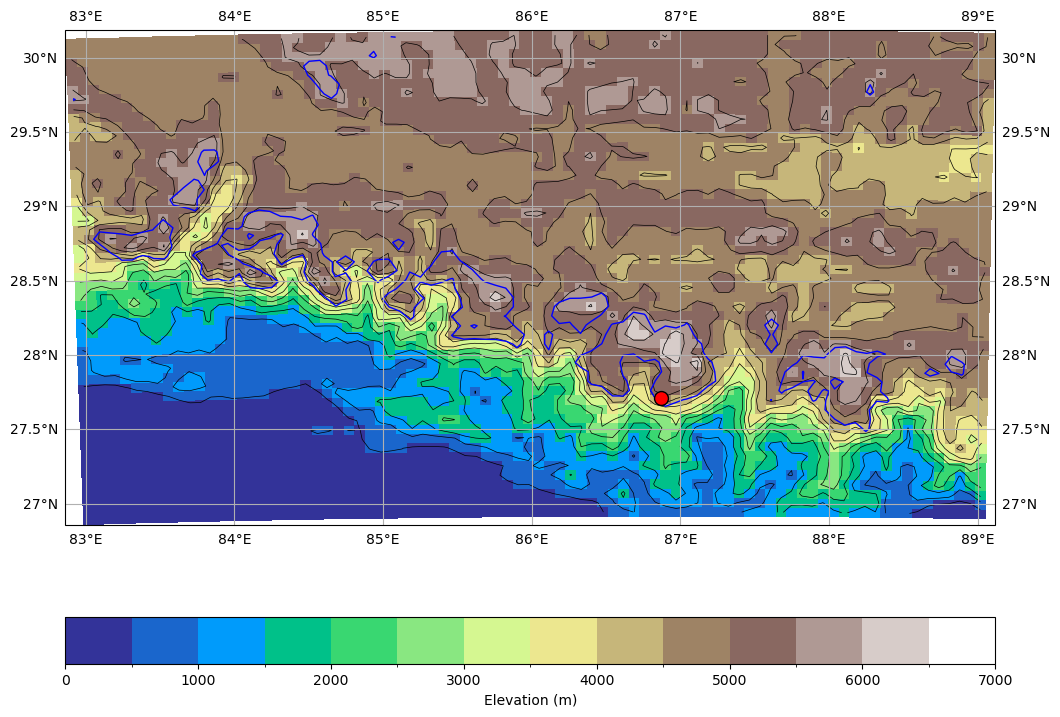

In [7]:
fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(ds_lon, ds_lat, ds_SH, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Countour glaciers ####
ax.contour(ds_lon, ds_lat, ds_ICE, 
           levels=[ice_level], # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level 
           colors="b", linewidths=1,
           transform=ccrs.PlateCarree())

#### Mera Peak coord ####
ax.plot(merap_lon, merap_lat,  
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

#### Topographie ####
im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                   cmap=cmap, norm=norm, # Affiche la couleur de la topographie
                   transform=ccrs.PlateCarree(),
                   shading="auto")

ax.gridlines(draw_labels=True) # Grille de lattitude et longitude
plt.colorbar(im, orientation="horizontal", pad=0.1, label="Elevation (m)") # Paramètres de la barre d'altitude (disposition horizontale / taille / légende)
plt.show()

# Carte de la région du Mera 

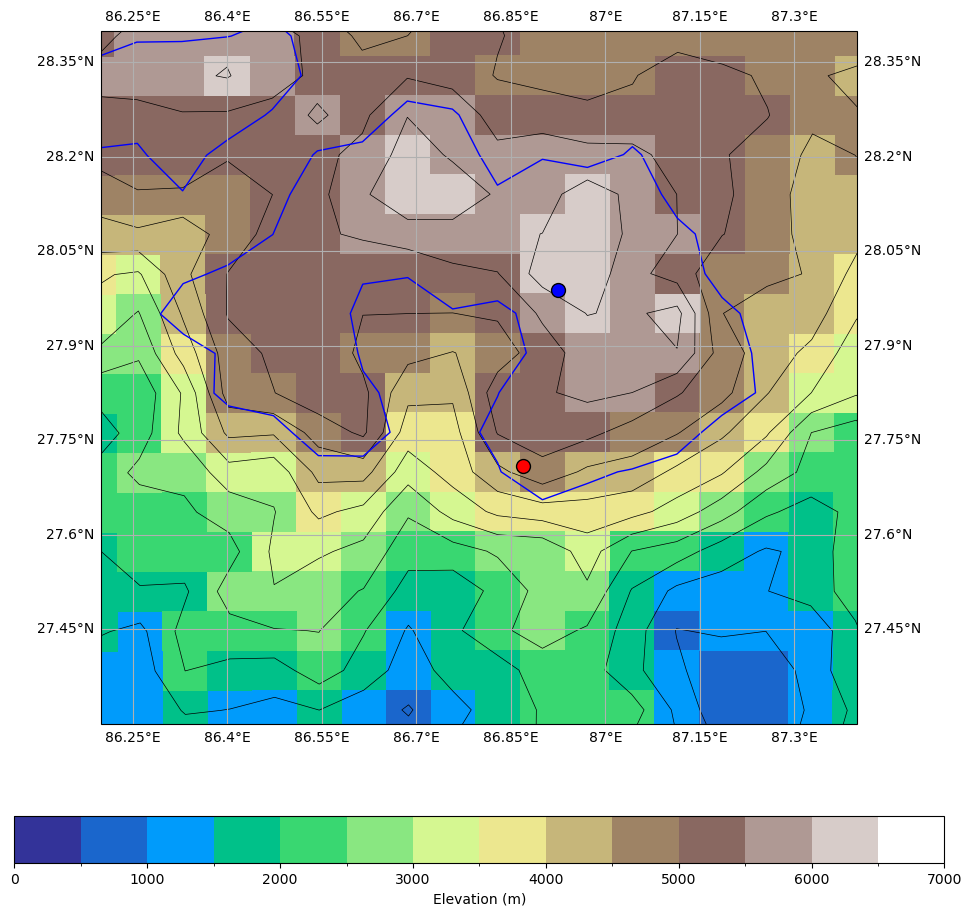

In [8]:
fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(ds_lon, ds_lat, ds_SH, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Countour glaciers ####
ax.contour(ds_lon, ds_lat, ds_ICE, 
           levels=[ice_level], # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level 
           colors="b", linewidths=1,
           transform=ccrs.PlateCarree())

#### Mera Peak coord ####
ax.plot(merap_lon, merap_lat,  # Coord exact du Mera Peak
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

#### Everest coord ####
ax.plot(everest_lon, everest_lat,  # Coord exact du Mera Peak
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='b',
        transform=ccrs.PlateCarree())

#### Topographie ####
im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                   cmap=cmap, norm=norm, # Affiche la couleur de la topographie
                   transform=ccrs.PlateCarree(),
                   shading="auto")

ax.set_extent([86.2, 87.4, 27.3, 28.4], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
#ax.set_extent([86.7, 87.1, 27.6, 27.9], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable zoom

ax.gridlines(draw_labels=True) # Grille de lattitude et longitude
plt.colorbar(im, orientation="horizontal", pad=0.1, label="Elevation (m)") # Paramètres de la barre d'altitude (disposition horizontale / taille / légende)
plt.show()

# Ice Map

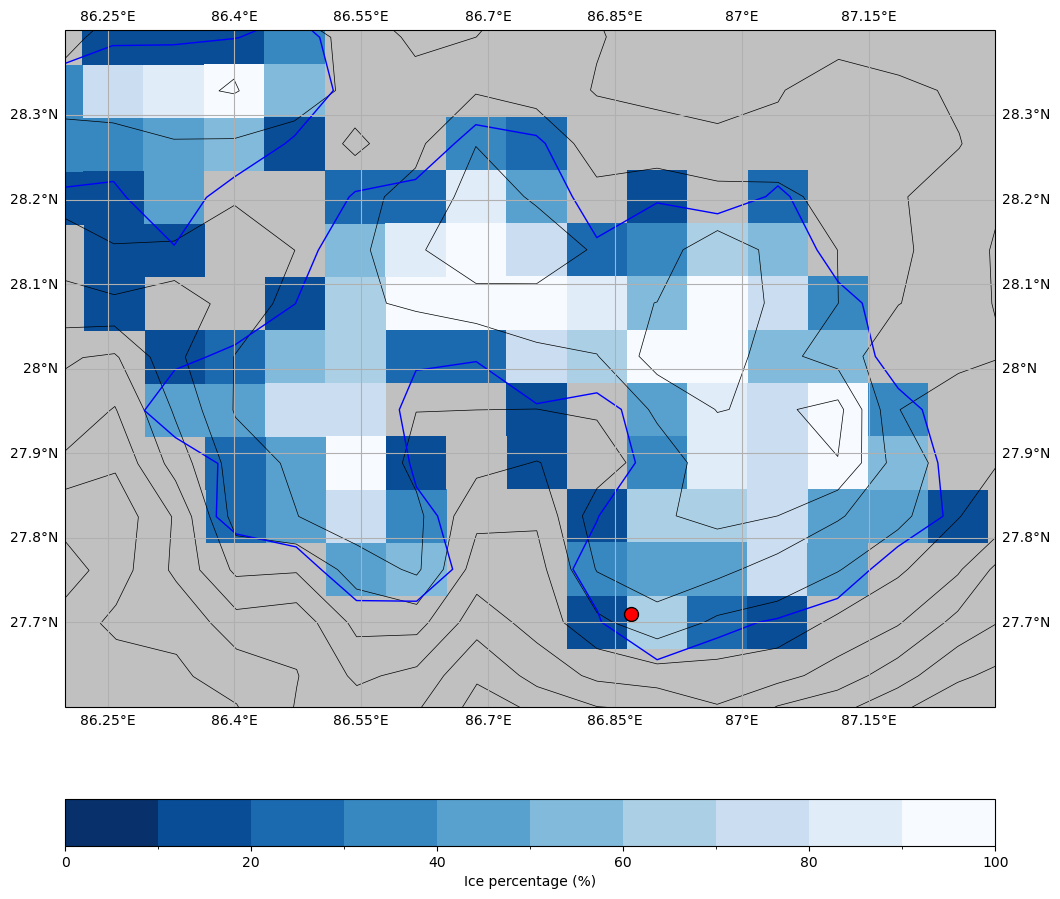

In [9]:
clevs = np.arange(0, 110, 10) # Echelle de couleur de 0 à 100% tous les 10%
cmap = plt.get_cmap("Blues_r") # Palette de couleur bleu (reverse) pour voir le % de glace par grille
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) 


fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

ax.set_facecolor('silver')
ICE_zero = np.ma.masked_where(ds_ICE ==0, ds_ICE) # Créer un mask sur les valeurs de % de glace nul
#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(ds_lon, ds_lat, ds_SH, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Countour glaciers ####
ax.contour(ds_lon, ds_lat, ds_ICE, 
           levels=[ice_level], # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level 
           colors="b", linewidths=1,
           transform=ccrs.PlateCarree())

#### Mera Peak coord ####
ax.plot(merap_lon, merap_lat,  # Coord exact du Mera Peak
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

#### Percentage of ice ####
im = ax.pcolormesh(ds_lon, ds_lat, ICE_zero,
                   cmap=cmap, norm=norm, # Affiche la couleur du % de glace
                   transform=ccrs.PlateCarree(),
                   shading="auto")

ax.set_extent([86.2, 87.3, 27.6, 28.4], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
#ax.set_extent([86.7, 87.1, 27.6, 27.9], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable zoom

ax.gridlines(draw_labels=True) # Grille de lattitude et longitude
plt.colorbar(im, orientation="horizontal", pad=0.1, label="Ice percentage (%)") # Paramètres de la barre d'altitude (disposition horizontale / taille / légende)
plt.show()

### Identification des indices X et Y de la grille correspondant au glacier Mera 
#### C'est à dire le point de grille le plus proche des coordonnées réelles

# Loading and sorting OBS data glacioclim

In [10]:
yy = [f"{i:02}" for i in range(7, 26)] # Liste des années sous le format yy

nyy = len(yy)-2

##### Définitions des variables accumulations et d'ablation pour le Mera(m) et Naulek(n) (Naulak n'a pas de balise en accu)
##### Mera Naulek #####
SMB_accu_m, SH_accu_m, reg_accu_m = [], [], []
SMB_ablation_m, SH_ablation_m, reg_ablation_m = [], [], []
SMB_ablation_n, SH_ablation_n, reg_ablation_n = [], [], []

date_obs, date_ref = [], [] # Stock les intervalles entre les mesures j et j-1 pour chaque année

##### Changri #####
SMB_chan, SH_chan, reg_chan = [], [], []
date_obs_chan, date_ref_chan = [], []

for j in range(nyy):
    
###### MERA/NAULEK OBS_data loading and sorting ######    
    df = pd.read_excel('/home/turpinli/Mera_SMB/AnnualMB_Mera_'+yy[j]+'_'+yy[j+1]+'.xlsx', header=1) #pandas permet ici de lire les fichiers .xlsx et prenant les colonnes à partir de la 2ème ligne

    glacier_col = df.columns[df.apply(lambda col: col.astype(str).str.contains("branch", na=False)).any()][0]

    
    ####### Recherche de la période moyenne (pondéré) ########
    df_clear = df.dropna(subset=["Date_start", "Date_end"]).reset_index(drop=True) # Suppression des lignes sans dates completes

    # Construction des variables
    t_start = pd.to_datetime(df_clear["Date_start"], format="%d/%m/%Y", errors="coerce") # Conversion en datetime 
    t_end   = pd.to_datetime(df_clear["Date_end"], format="%d/%m/%Y", errors="coerce")
    duration = (t_end - t_start).dt.total_seconds() # Durée de chaque période Δt_i (transformé en seconde)
    t_mid = t_start + (t_end - t_start) / 2 # Milieu de chaque intervalle

    # Moyenne pondérée du centre temporel
    t_mid_sec = t_mid.astype("int64") / 1e9 # Conversion dates en secondes
    weighted_mid = np.sum(t_mid_sec * duration) / np.sum(duration) 
    weighted_mid = pd.to_datetime(weighted_mid, unit="s") # Reconversion en date
    weighted_duration = np.sum(duration * duration) / np.sum(duration) # Δt = sum(w_i * Δt_i) / sum(w_i). On fait la moyenne pondérée par elle même
    weighted_duration = pd.to_timedelta(weighted_duration, unit="s") # Reconversion en date

    date_ref.append((weighted_mid - weighted_duration / 2).replace(hour=12)) # Reconstruction de la période centrée sur le temps moyen t_ref = t_mid - Δt/2
    date_obs.append((weighted_mid + weighted_duration / 2).replace(hour=12))

    
    ######## Récupération MB ########
    MB = df.filter(regex=r"^Mass balance \(").columns[0] # Regex recupère les données dans la colonne Mass balance, peut importe ce qui suit dans la chaine de caractères 
    df[MB] = pd.to_numeric(df[MB], errors="coerce") # Force la colonne à prendre la forme d'un nombre (car unité en haut de colonne)
    df["Altitude_end"] = pd.to_numeric(df["Altitude_end"], errors="coerce") # Coerce donne NaN si la valeur n'est pas convertible en nombre

    df = df.dropna(subset=["Altitude_end",MB]) # Supprime les NaN dans les colonnes

    df_ablation = df[df["#station"].str.match(r"^\d") | (df["#station"] == "AWS")] # Catégorise les stations qui commencent par un chiffre ou qui sont strictement AWS, en ablaion
    df_accu = df[~(df["#station"].str.match(r"^\d") | (df["#station"] == "AWS"))] # Le ~ est la condition "not" --> Tout le reste / (r"^\d" identifie les chiffres) et "|" vérifie les deux conditions 

    df_accu_m   = df_accu[df_accu[glacier_col] == "Mera branch"]
    df_ablation_m   = df_ablation[df_ablation[glacier_col] == "Mera branch"]
    df_ablation_n = df_ablation[df_ablation[glacier_col] == "Naulek branch"]
    
    ###### Accumulation ######
    x_accu_m = df_accu_m[MB]
    y_accu_m = df_accu_m["Altitude_end"]
    
    if len(x_accu_m) >= 2:
        res_accu_m = stats.linregress(x_accu_m, y_accu_m)

    SMB_accu_m.append(x_accu_m)
    SH_accu_m.append(y_accu_m)
    reg_accu_m.append(res_accu_m)

    ##### Ablation ######
    x_ablation_m = df_ablation_m[MB]
    y_ablation_m = df_ablation_m["Altitude_end"]

    x_ablation_n = df_ablation_n[MB]
    y_ablation_n = df_ablation_n["Altitude_end"]

    if len(x_ablation_m) >= 2:
        res_ablation_m = stats.linregress(x_ablation_m, y_ablation_m)

    if len(x_ablation_n) >= 2:
        res_ablation_n = stats.linregress(x_ablation_n, y_ablation_n)
        
    SMB_ablation_m.append(x_ablation_m)
    SH_ablation_m.append(y_ablation_m)
    reg_ablation_m.append(res_ablation_m)

    SMB_ablation_n.append(x_ablation_n)
    SH_ablation_n.append(y_ablation_n)
    reg_ablation_n.append(res_ablation_n)


    

    ###### CHANGRI NUP OBS_data loading and sorting ######    
    file_changri = '/home/turpinli/Changri_data/AnnualMB_West_Changri_Nup_'+yy[j]+'_'+yy[j+1]+'.xlsx'

    if os.path.exists(file_changri): # Selectionne que les fichiers où les années sont présentes
        dfc = pd.read_excel(file_changri, header=1) #pandas permet ici de lire les fichiers .xlsx et prenant les colonnes à partir de la 2ème ligne
    
        ####### Recherche de la période moyenne (pondéré) ########
        dfc_clear = dfc.dropna(subset=["Date_start", "Date_end"]).reset_index(drop=True) # Suppression des lignes sans dates completes

        # Construction des variables
        t_start = pd.to_datetime(dfc_clear["Date_start"], format="%d/%m/%Y", errors="coerce") # Conversion en datetime 
        t_end   = pd.to_datetime(dfc_clear["Date_end"], format="%d/%m/%Y", errors="coerce")
        duration = (t_end - t_start).dt.total_seconds() # Durée de chaque période Δt_i (transformé en seconde)
        t_mid = t_start + (t_end - t_start) / 2 # Milieu de chaque intervalle

        # Moyenne pondérée du centre temporel
        t_mid_sec = t_mid.astype("int64") / 1e9 # Conversion dates en secondes
        weighted_mid = np.sum(t_mid_sec * duration) / np.sum(duration) 
        weighted_mid = pd.to_datetime(weighted_mid, unit="s") # Reconversion en date
        weighted_duration = np.sum(duration * duration) / np.sum(duration) # Δt = sum(w_i * Δt_i) / sum(w_i). On fait la moyenne pondérée par elle même
        weighted_duration = pd.to_timedelta(weighted_duration, unit="s") # Reconversion en date

        date_ref_c = (weighted_mid - weighted_duration / 2).replace(hour=12) # Reconstruction de la période centrée sur le temps moyen t_ref = t_mid - Δt/2
        date_obs_c = (weighted_mid + weighted_duration / 2).replace(hour=12)
    
        ######## Récupération MB ########
        MBc = dfc.filter(regex=r"^Mass balance \(").columns[0] # Regex recupère les données dans la colonne Mass balance, peut importe ce qui suit dans la chaine de caractères 
        dfc[MBc] = pd.to_numeric(dfc[MBc], errors="coerce") # Force la colonne à prendre la forme d'un nombre (car unité en haut de colonne)
        dfc["Altitude_end"] = pd.to_numeric(dfc["Altitude_end"], errors="coerce") # Coerce donne NaN si la valeur n'est pas convertible en nombre
    
        dfc = dfc.dropna(subset=["Altitude_end",MBc]) # Supprime les NaN dans les colonnes
    
        x_chan = dfc[MBc] # Valeurs de SMB
        y_chan = dfc["Altitude_end"] # Valeurs d'altitude
    
        if len(x_chan) >= 2:
            res_chan= stats.linregress(x_chan, y_chan)

    else: # Si pour un yy on ne trouve pas d'année de changri nup, alors on assigne rien à ces listes
        x_chan, y_chan, res_chan = [], [], None
        date_ref_c, date_obs_c = None, None

    SMB_chan.append(x_chan)
    SH_chan.append(y_chan)
    reg_chan.append(res_chan)
    date_ref_chan.append(date_ref_c)
    date_obs_chan.append(date_obs_c)

# Loading MAR data 

In [11]:
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq_bug/spin2/work/daily/' 

SMB_year = []

for j in range(nyy):
    ###### MAR_data loading and sorting  ######    
    file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_20'+yy[j+1]+'.nc'
    ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() # Sector correspond à des types d'occupation des sols en % (ex: 30% de la grille occupé par de la végétation)
    ds_SMBy = ds_SMBy[:,k:-k,k:-k]
    ds_ICE_mask = ds_ICE_mask.assign_coords(Y=ds_SMBy.Y, X=ds_SMBy.X) # Force le ICE_mask a être sur la même grille que le SMB
    ds_SMBy = ds_SMBy.where(ds_ICE_mask) # On fait directement un tri sur les données. Seuls les points de grille avec de la glace >= ice_level seront reconnus
    SMB_year.append(ds_SMBy)

####### Style of map 3x3 or khumbu #####
clevs = np.arange(0, 7500, 500) # Echelle de couleur de topographie de 0 à 7500 tout les 500m d'alt
cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) # Attribut à chaque bande d'altitude une couleur de la palette "terrain"


Grid alt = 4831.3545 m


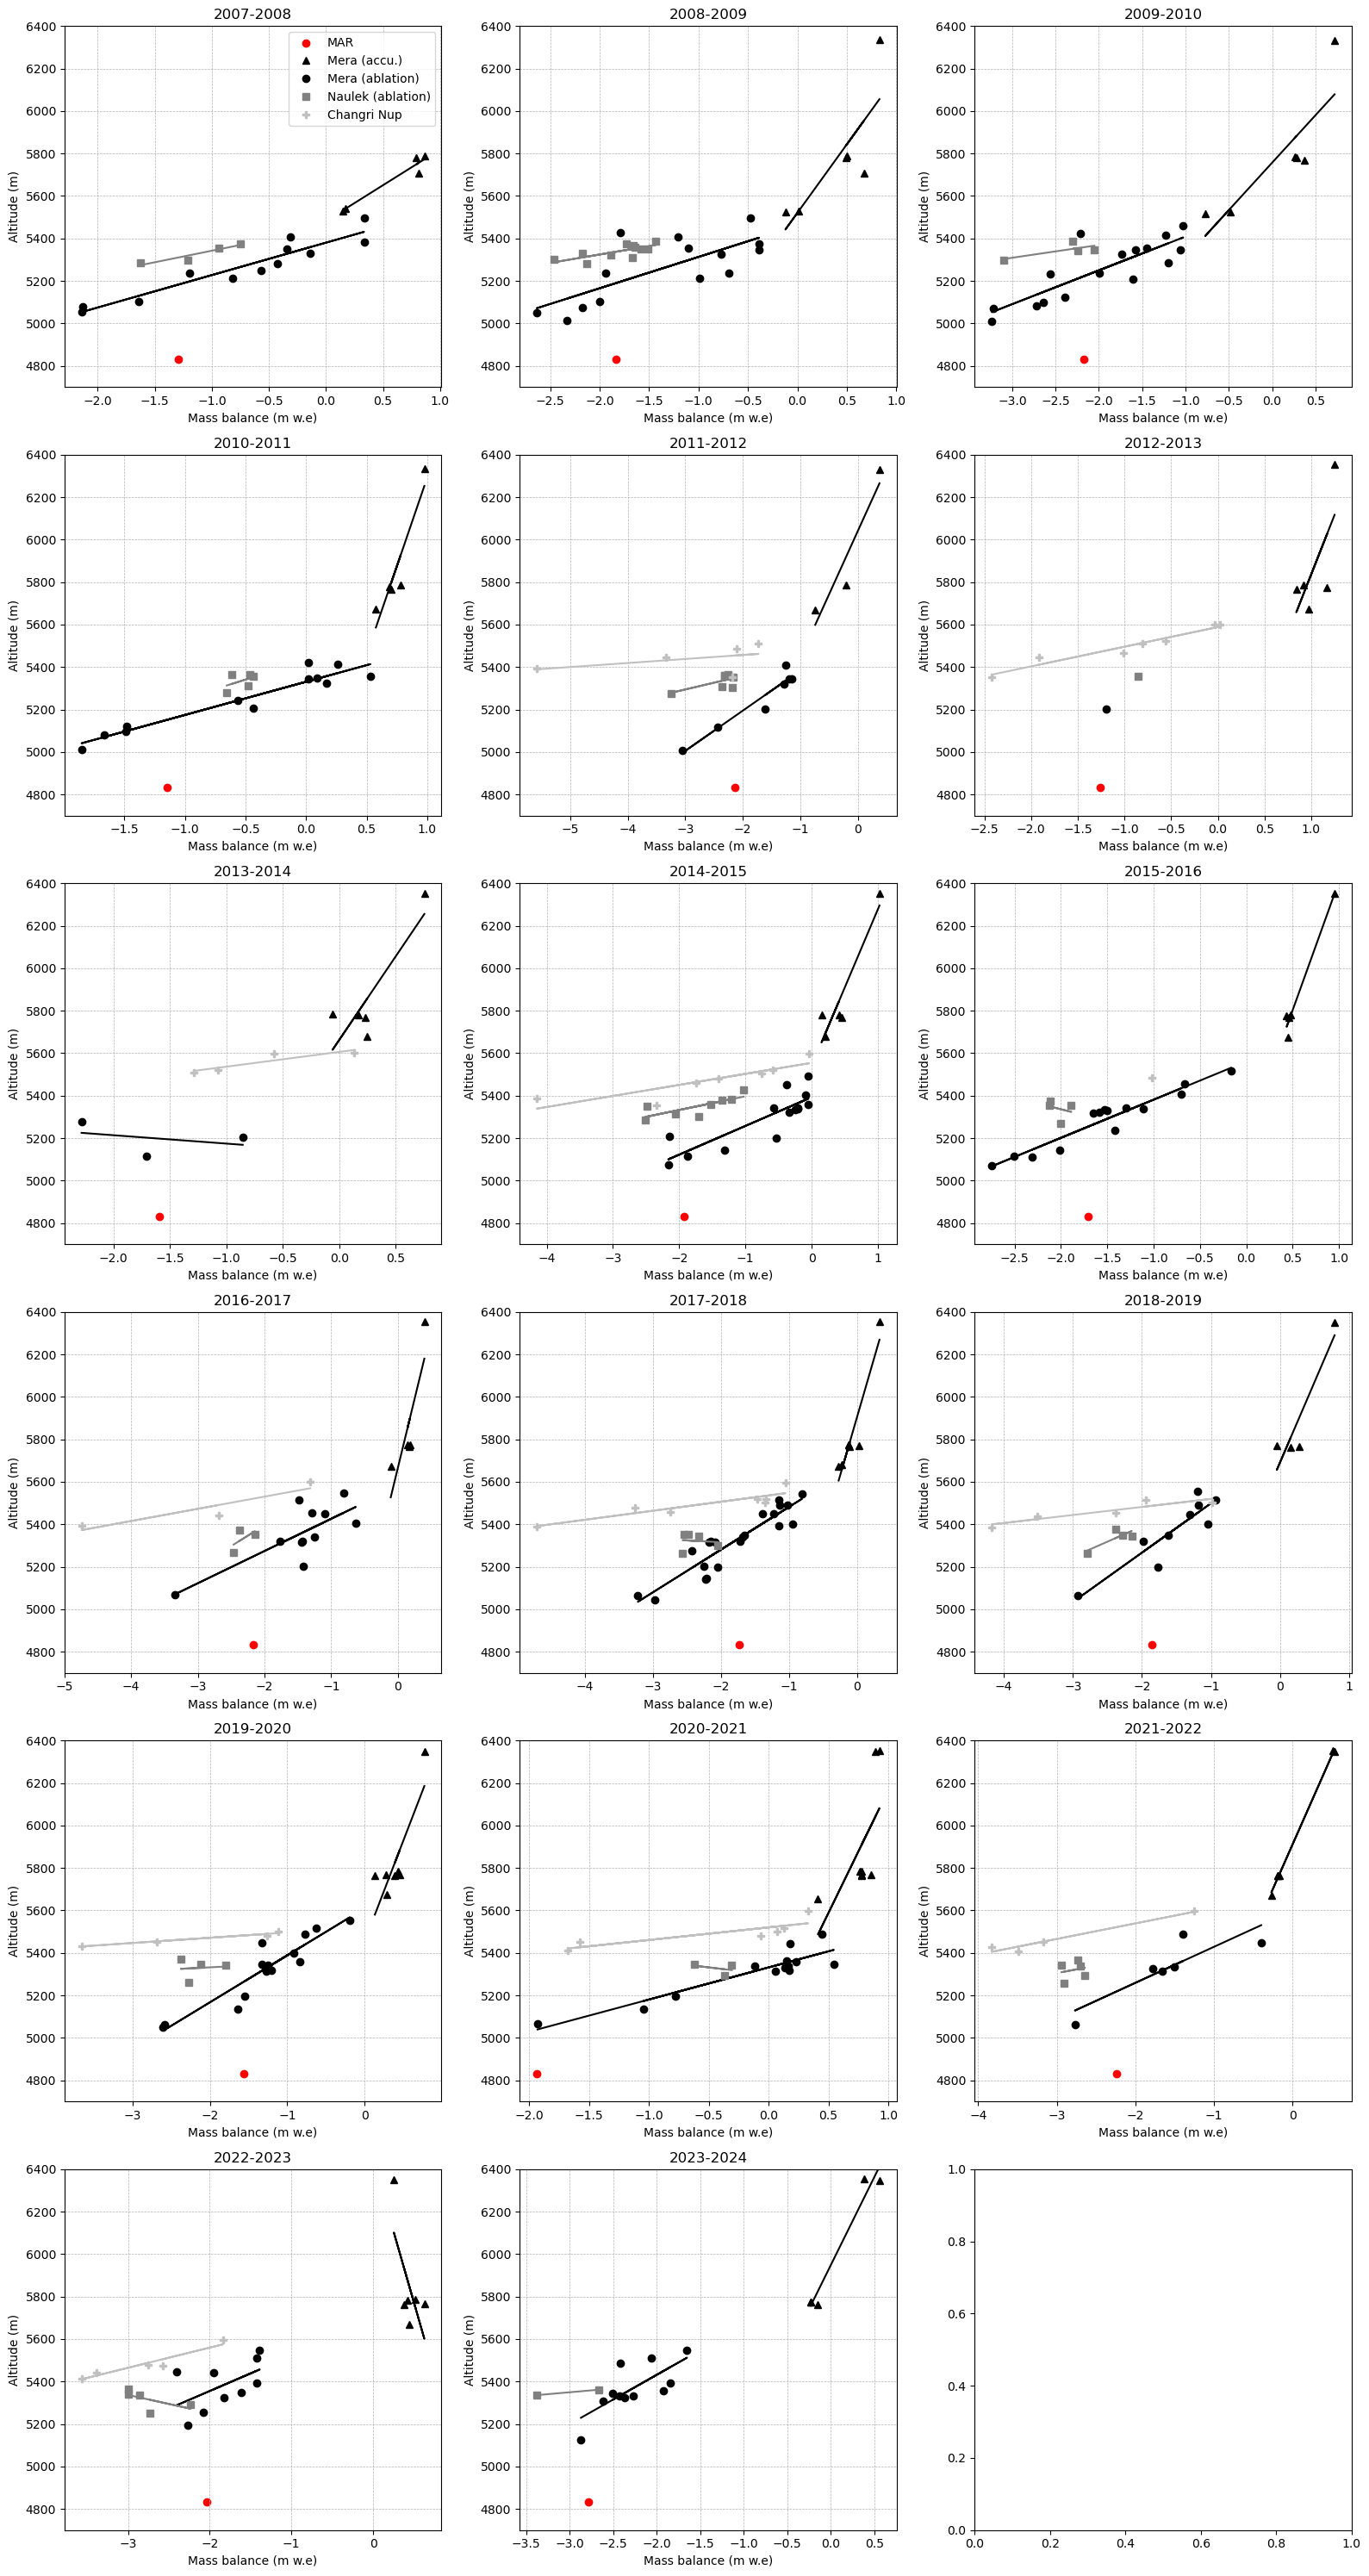

In [12]:
### Mera grid point
col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))

SMB_list_Mera = []

for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle
    
    ###### MAR_data loading and sorting  ######   
    SMB_day = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=iY, X=iX) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum = SMB_day.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR = SMB_sum.values
    SMB_list_Mera.append(SMB_MAR)

    SH_MAR = ds_SH.isel(y=iY, x=iX) # Altitude de la grille de MAR au Peak Mera (coord iY,iX)
    
    ax.scatter(SMB_MAR, SH_MAR, color="r", label="MAR") # Affiche le point de MAR correspondant à la date des obs

    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="^", color='k', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'k') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='k', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], color='k') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="s", color='gray', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'gray') # Naulek ablation regression

    ##### Changri Nup
    ax.plot(SMB_chan[j], SH_chan[j], linestyle="", marker="P", color='silver', label='Changri Nup') # Changri Nup
    
    if reg_chan[j] is not None: # Si on était à une année sans données de chagri on n'affiche pas sa régression linéaire
        ax.plot(SMB_chan[j], reg_chan[j].intercept + reg_chan[j].slope * SMB_chan[j], 'silver') # Changri Nup regression lineaire
    
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
#    ax.set_xlim(-4, 2)
    ax.set_ylim(4700, 6400)
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()
print('Grid alt =', SH_MAR.values, 'm')
plt.tight_layout()
plt.savefig("Changri.png")

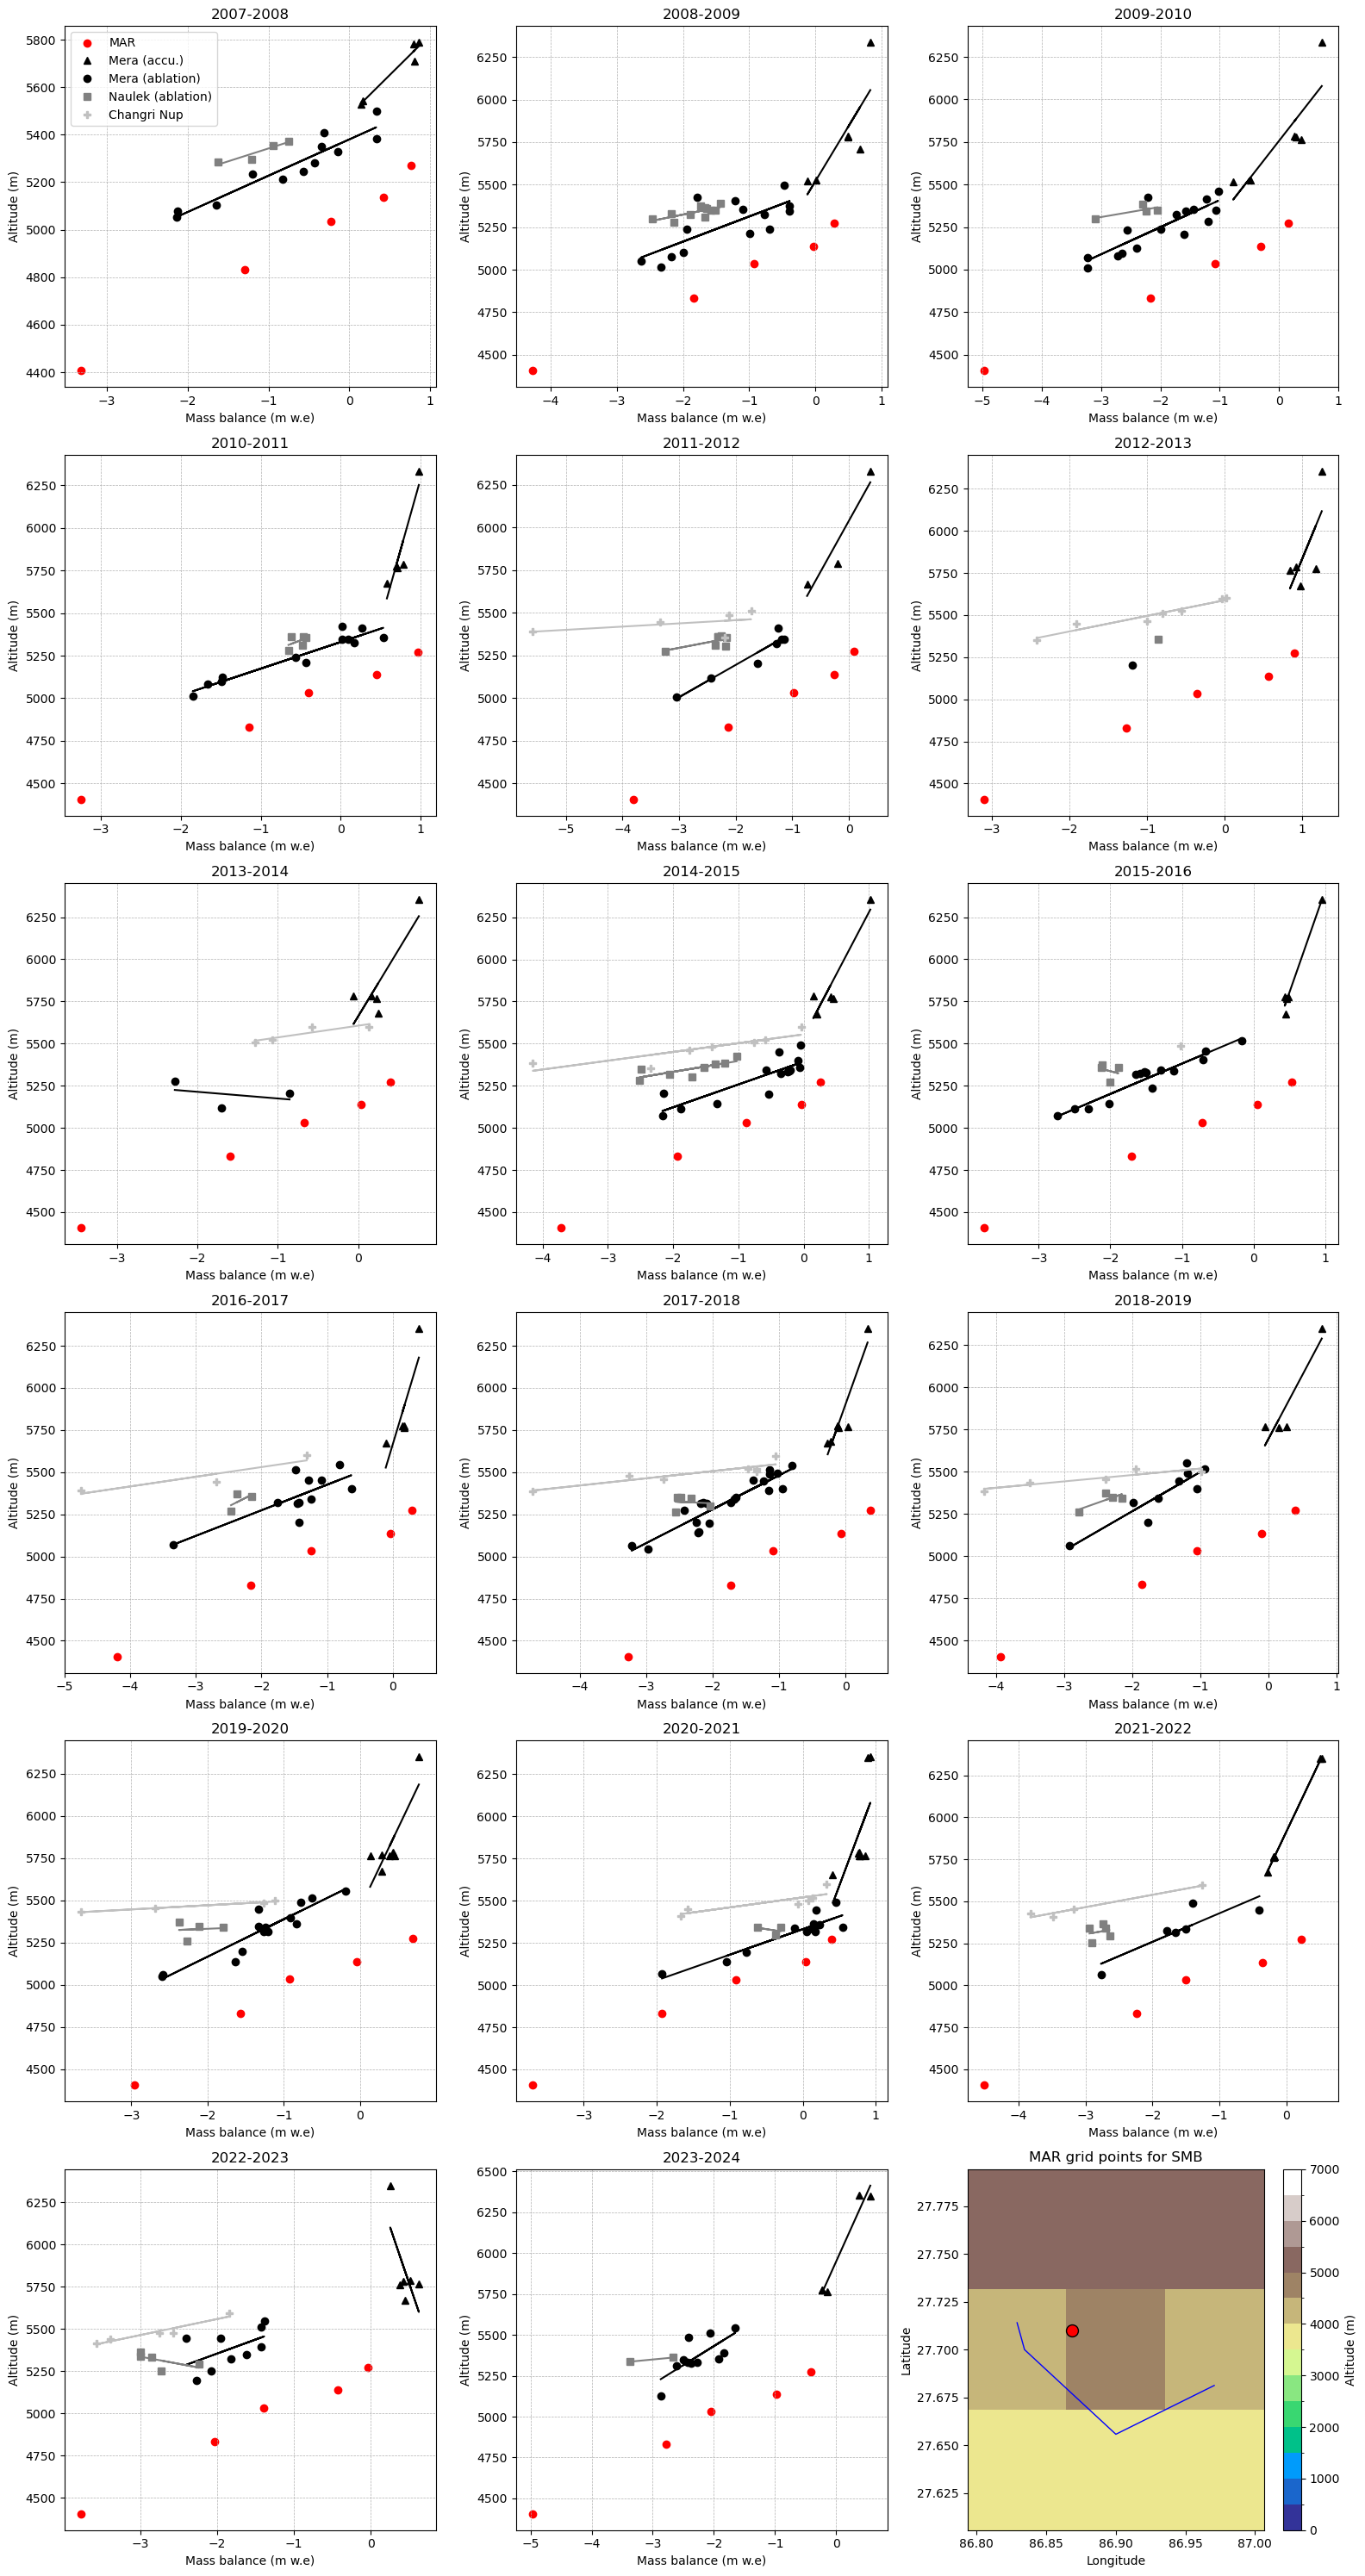

In [13]:
### 3x3 grid around Mera

Ydown, Yup, Xleft, Xright = iY-1, iY+2, iX-1, iX+2 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))


####### Grid on last subplot ######
ax = axes[nyy]
ds_SH_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne le SMB sur les grilles données
ds_ICE_khumbu = ds_ICE.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))
ds_lat_khumbu = ds_lat.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne les lon lat pour les plot
ds_lon_khumbu = ds_lon.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")


####### Subplot filling ###### 
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######    
    SMB_day2 = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum2 = SMB_day2.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR2 = SMB_sum2.values.flatten()
 
    SH_MAR2 = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    mask_zero = SMB_MAR2 != 0 # Masque les valeurs=0 qui ont pu être générés par le ice_level
    SMB_MAR2 = SMB_MAR2[mask_zero]
    SH_MAR2 = SH_MAR2[mask_zero]
    
    ax.scatter(SMB_MAR2, SH_MAR2, color="r", label="MAR") # Affiche les points de MAR correspondant à la date des obs

    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="^", color='k', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'k') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='k', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], color='k') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="s", color='gray', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'gray') # Naulek ablation regression

    ##### Changri Nup
    ax.plot(SMB_chan[j], SH_chan[j], linestyle="", marker="P", color='silver', label='Changri Nup') # Changri Nup
    
    if reg_chan[j] is not None: # Si on était à une année sans données de chagri on n'affiche pas sa régression linéaire
        ax.plot(SMB_chan[j], reg_chan[j].intercept + reg_chan[j].slope * SMB_chan[j], 'silver') # Changri Nup regression lineaire
   
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)
    #ax.set_xlim(-4, 2) # Restriction du domaine 
    #ax.set_ylim(4700, 6400) # Restriction du domaine 
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()

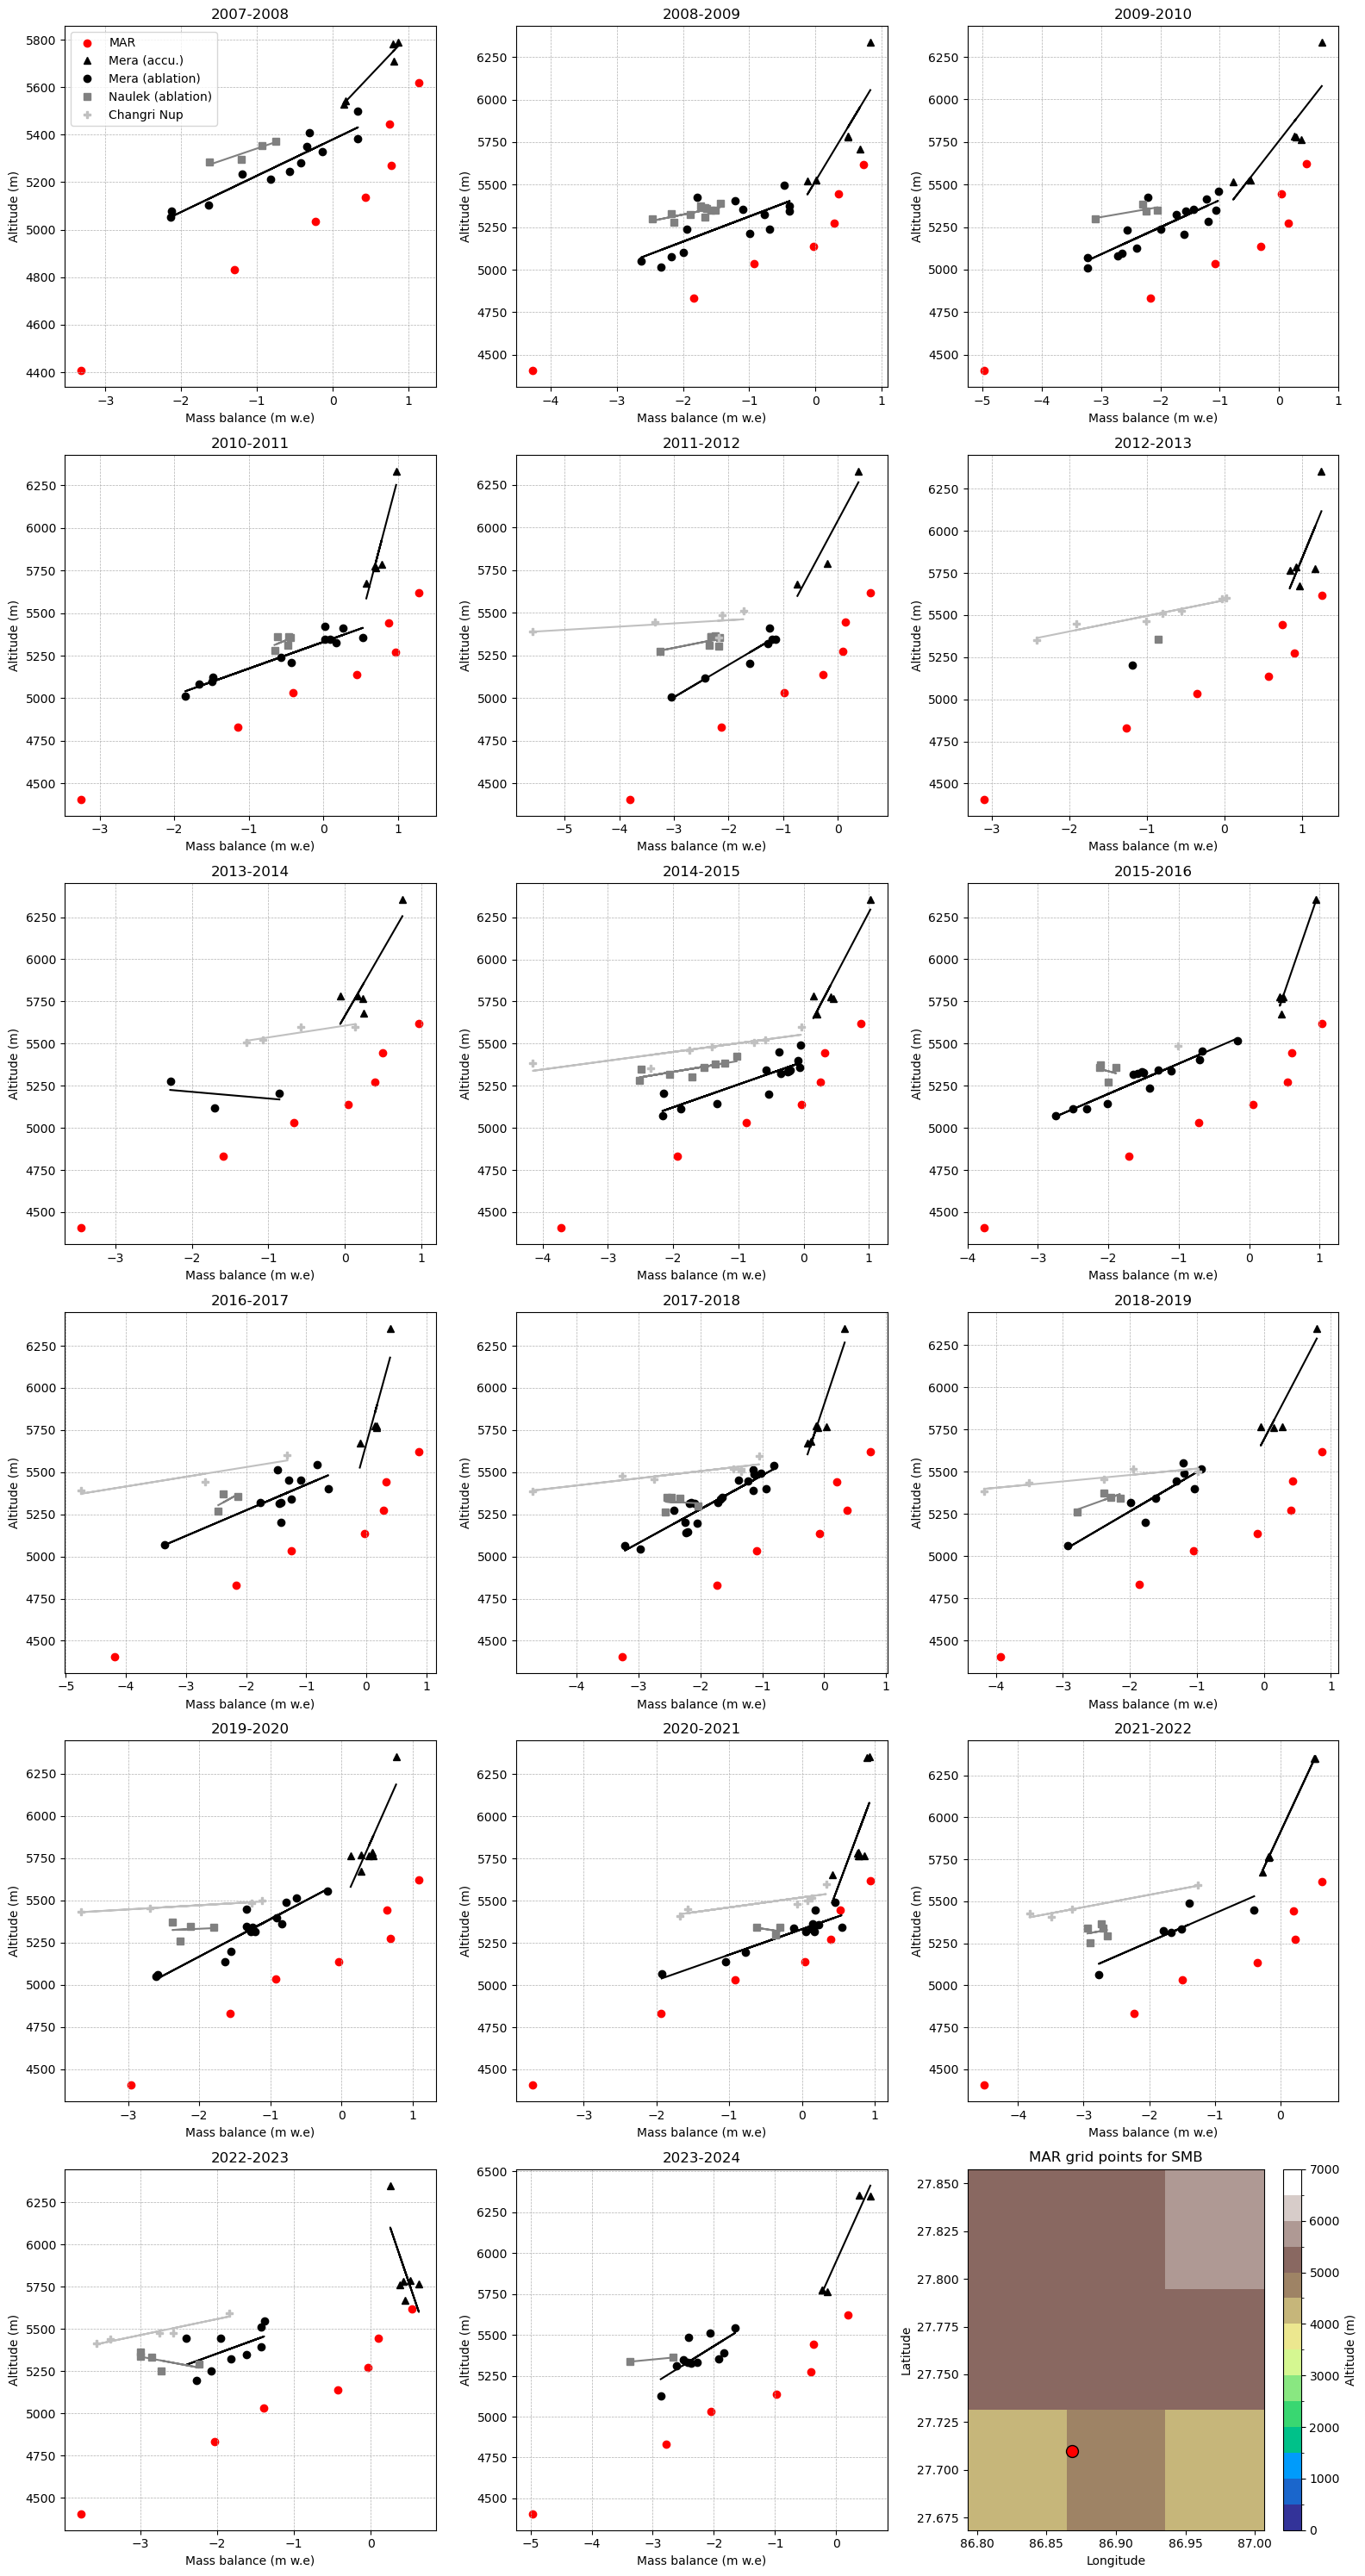

In [14]:
### 3x3 grid North of Mera

Ydown, Yup, Xleft, Xright = iY, iY+3, iX-1, iX+2 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))


####### Grid on last subplot ######
ax = axes[nyy]
ds_SH3 = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne le SMB sur les grilles données
ds_lat_mera3 = ds_lat.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne les lon lat pour les plot
ds_lon_mera3 = ds_lon.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))

ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_mera3, ds_lat_mera3, ds_SH3, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")


####### Subplot filling ###### 
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######    
    SMB_day3 = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum3 = SMB_day3.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR3 = SMB_sum3.values.flatten() 

    SH_MAR3 = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    mask_zero = SMB_MAR3 != 0 # Masque les valeurs=0 qui ont pu être générés par le ice_level
    SMB_MAR3 = SMB_MAR3[mask_zero]
    SH_MAR3 = SH_MAR3[mask_zero]

    ax.scatter(SMB_MAR3, SH_MAR3, color="r", label="MAR") # Affiche les points de MAR correspondant à la date des obs

    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="^", color='k', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'k') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='k', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], color='k') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="s", color='gray', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'gray') # Naulek ablation regression

    ##### Changri Nup
    ax.plot(SMB_chan[j], SH_chan[j], linestyle="", marker="P", color='silver', label='Changri Nup') # Changri Nup
    
    if reg_chan[j] is not None: # Si on était à une année sans données de chagri on n'affiche pas sa régression linéaire
        ax.plot(SMB_chan[j], reg_chan[j].intercept + reg_chan[j].slope * SMB_chan[j], 'silver') # Changri Nup regression lineaire
    
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)

    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()

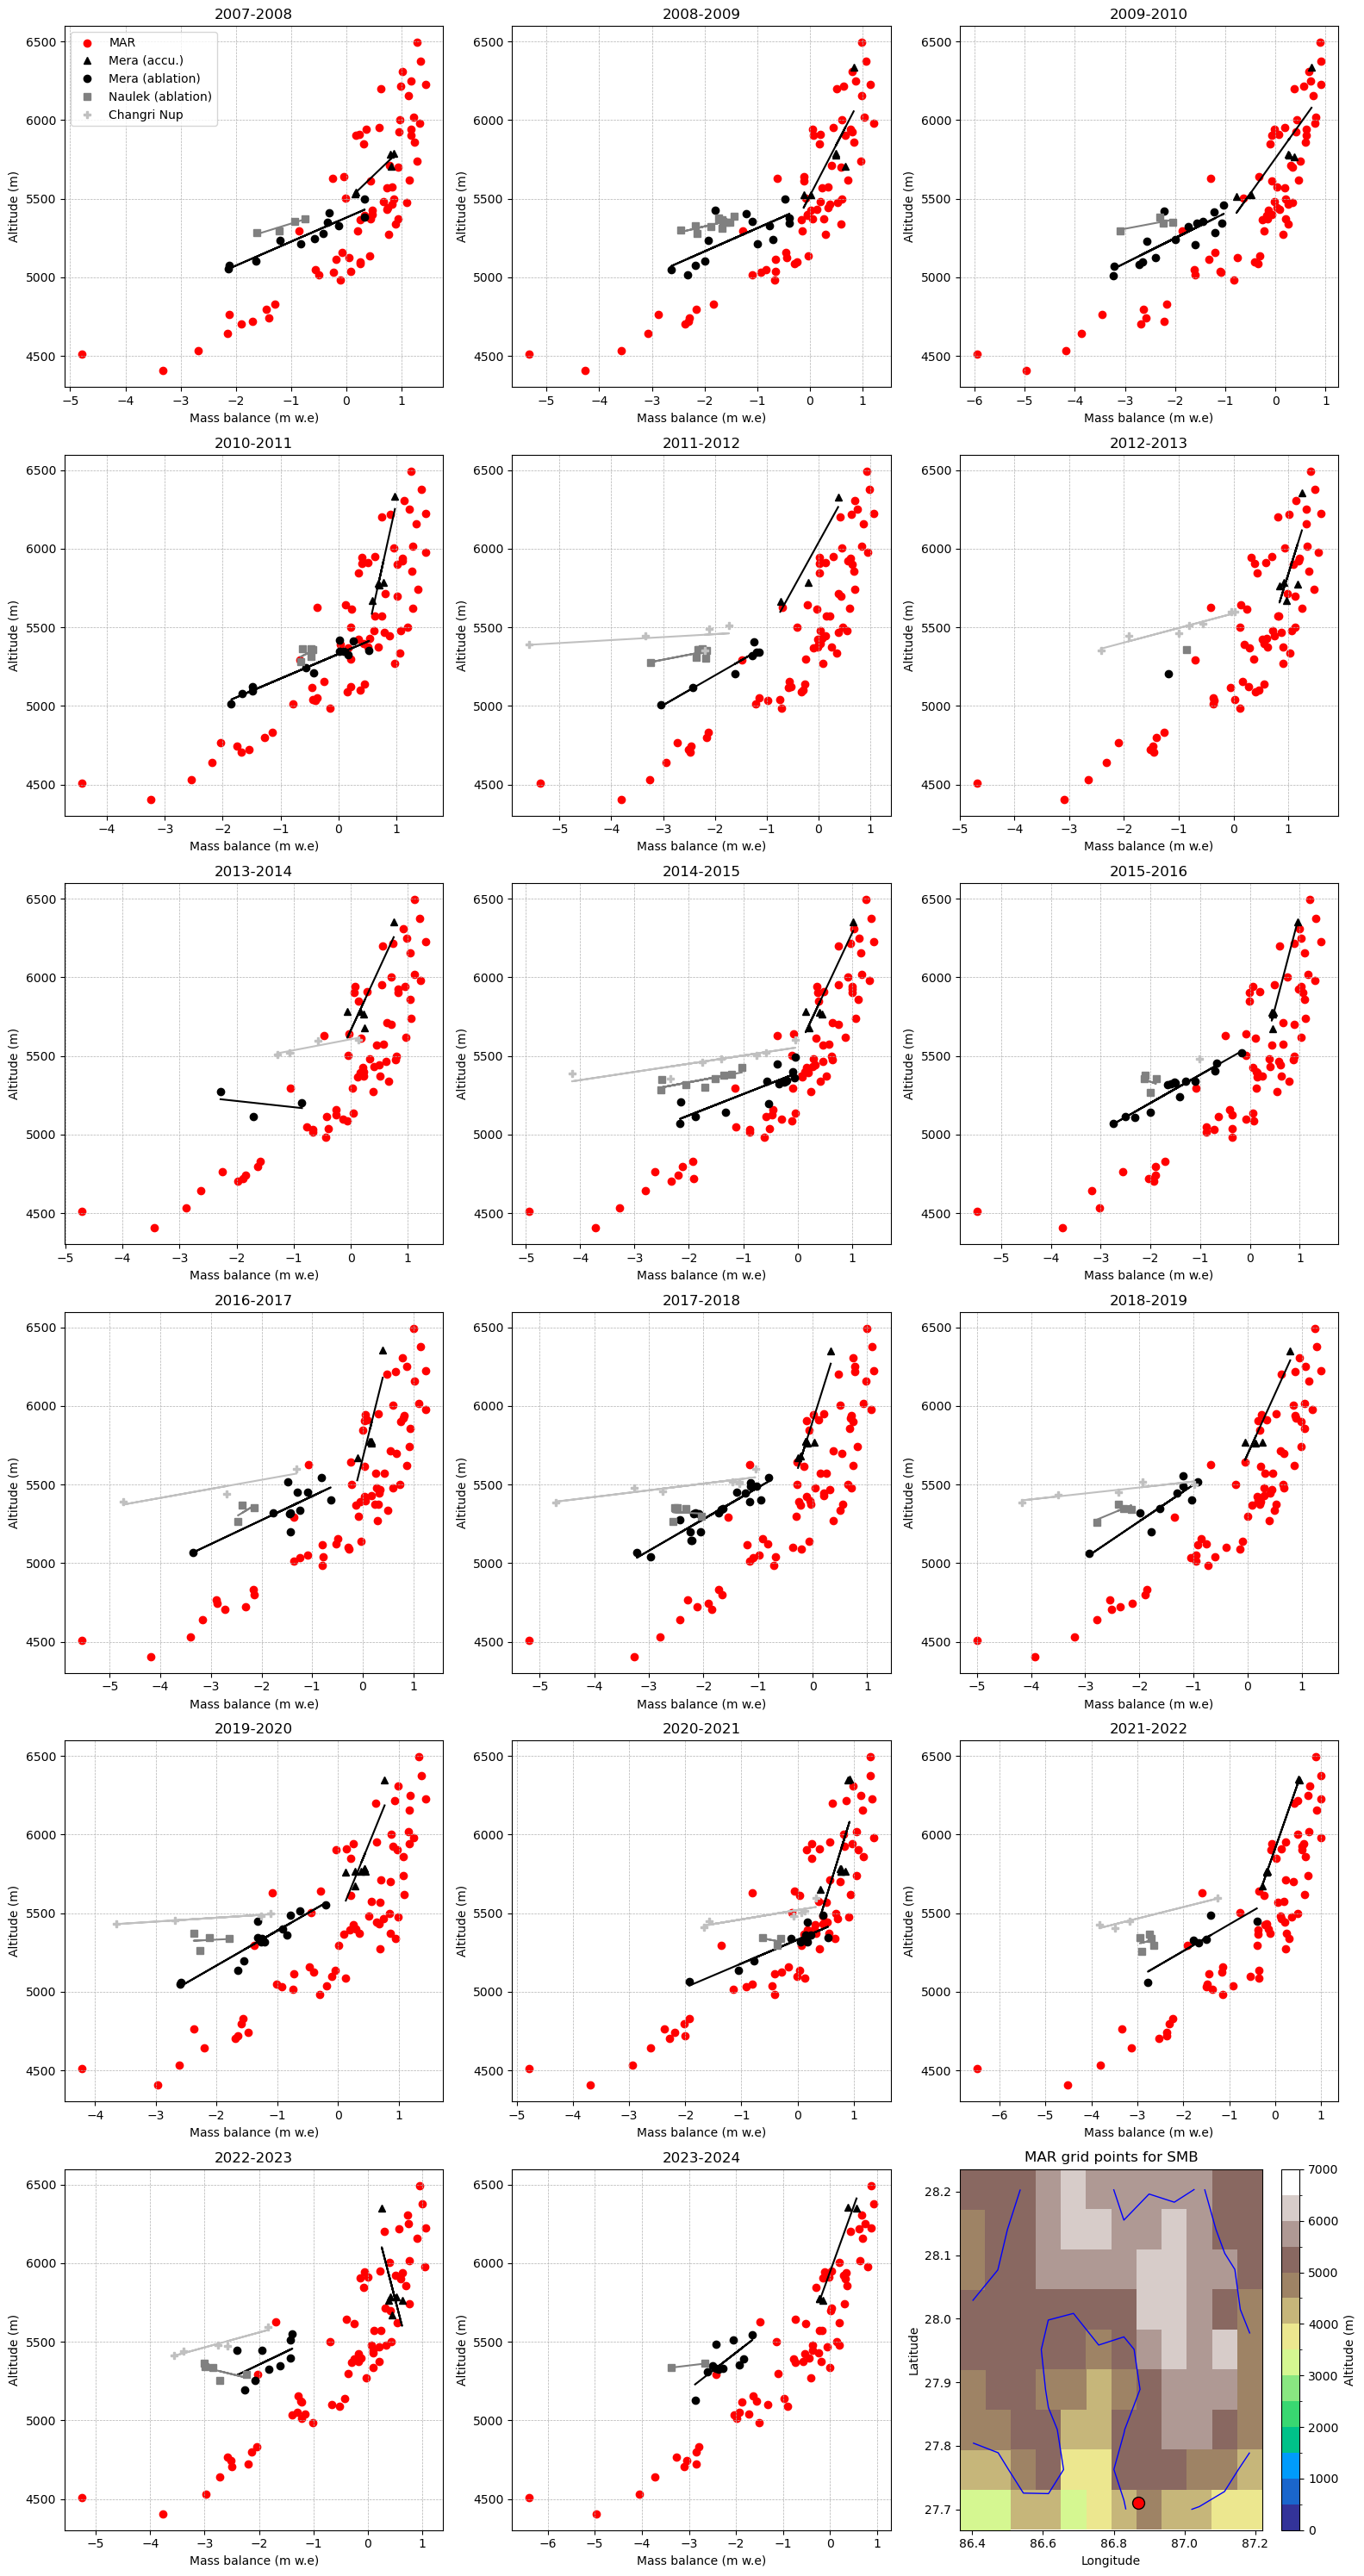

In [15]:
### Khumbu domain

Ydown, Yup, Xleft, Xright = iY, iY+9, iX-7, iX+5 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))

SMB_list_khumbu = []

####### Grid on last subplot ######
ax = axes[nyy]
ds_SH_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne le SMB sur les grilles données
ds_ICE_khumbu = ds_ICE.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))
ds_lat_khumbu = ds_lat.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne les lon lat pour les plot
ds_lon_khumbu = ds_lon.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")


####### Subplot filling ###### 
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######    
    SMB_day_khumbu = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté des valeurs journalière sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten()
    SH_MAR_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    mask_zero = SMB_MAR_khumbu != 0 # Masque les valeurs=0 qui ont pu être générés par le ice_level
    SMB_MAR_khumbu = SMB_MAR_khumbu[mask_zero]
    SH_MAR_khumbu = SH_MAR_khumbu[mask_zero]

    # Prepare les données pour les plot en série temporelle (ici on retire les valeurs de SMB=0)
    SMB_regional = SMB_sum_khumbu.where(SMB_sum_khumbu != 0).mean(dim=["Y","X"]).values # Fais la moyenne des SMB de chaque point de grille du khumbu pour chaque année
    SMB_list_khumbu.append(SMB_regional)
    
    ax.scatter(SMB_MAR_khumbu, SH_MAR_khumbu, color="r", label="MAR") # Affiche les points de MAR correspondant à la date des obs

    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="^", color='k', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'k') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='k', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], color='k') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="s", color='gray', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'gray') # Naulek ablation regression

    ##### Changri Nup
    ax.plot(SMB_chan[j], SH_chan[j], linestyle="", marker="P", color='silver', label='Changri Nup') # Changri Nup
    
    if reg_chan[j] is not None: # Si on était à une année sans données de chagri on n'affiche pas sa régression linéaire
        ax.plot(SMB_chan[j], reg_chan[j].intercept + reg_chan[j].slope * SMB_chan[j], 'silver') # Changri Nup regression lineaire
    
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()
plt.tight_layout()

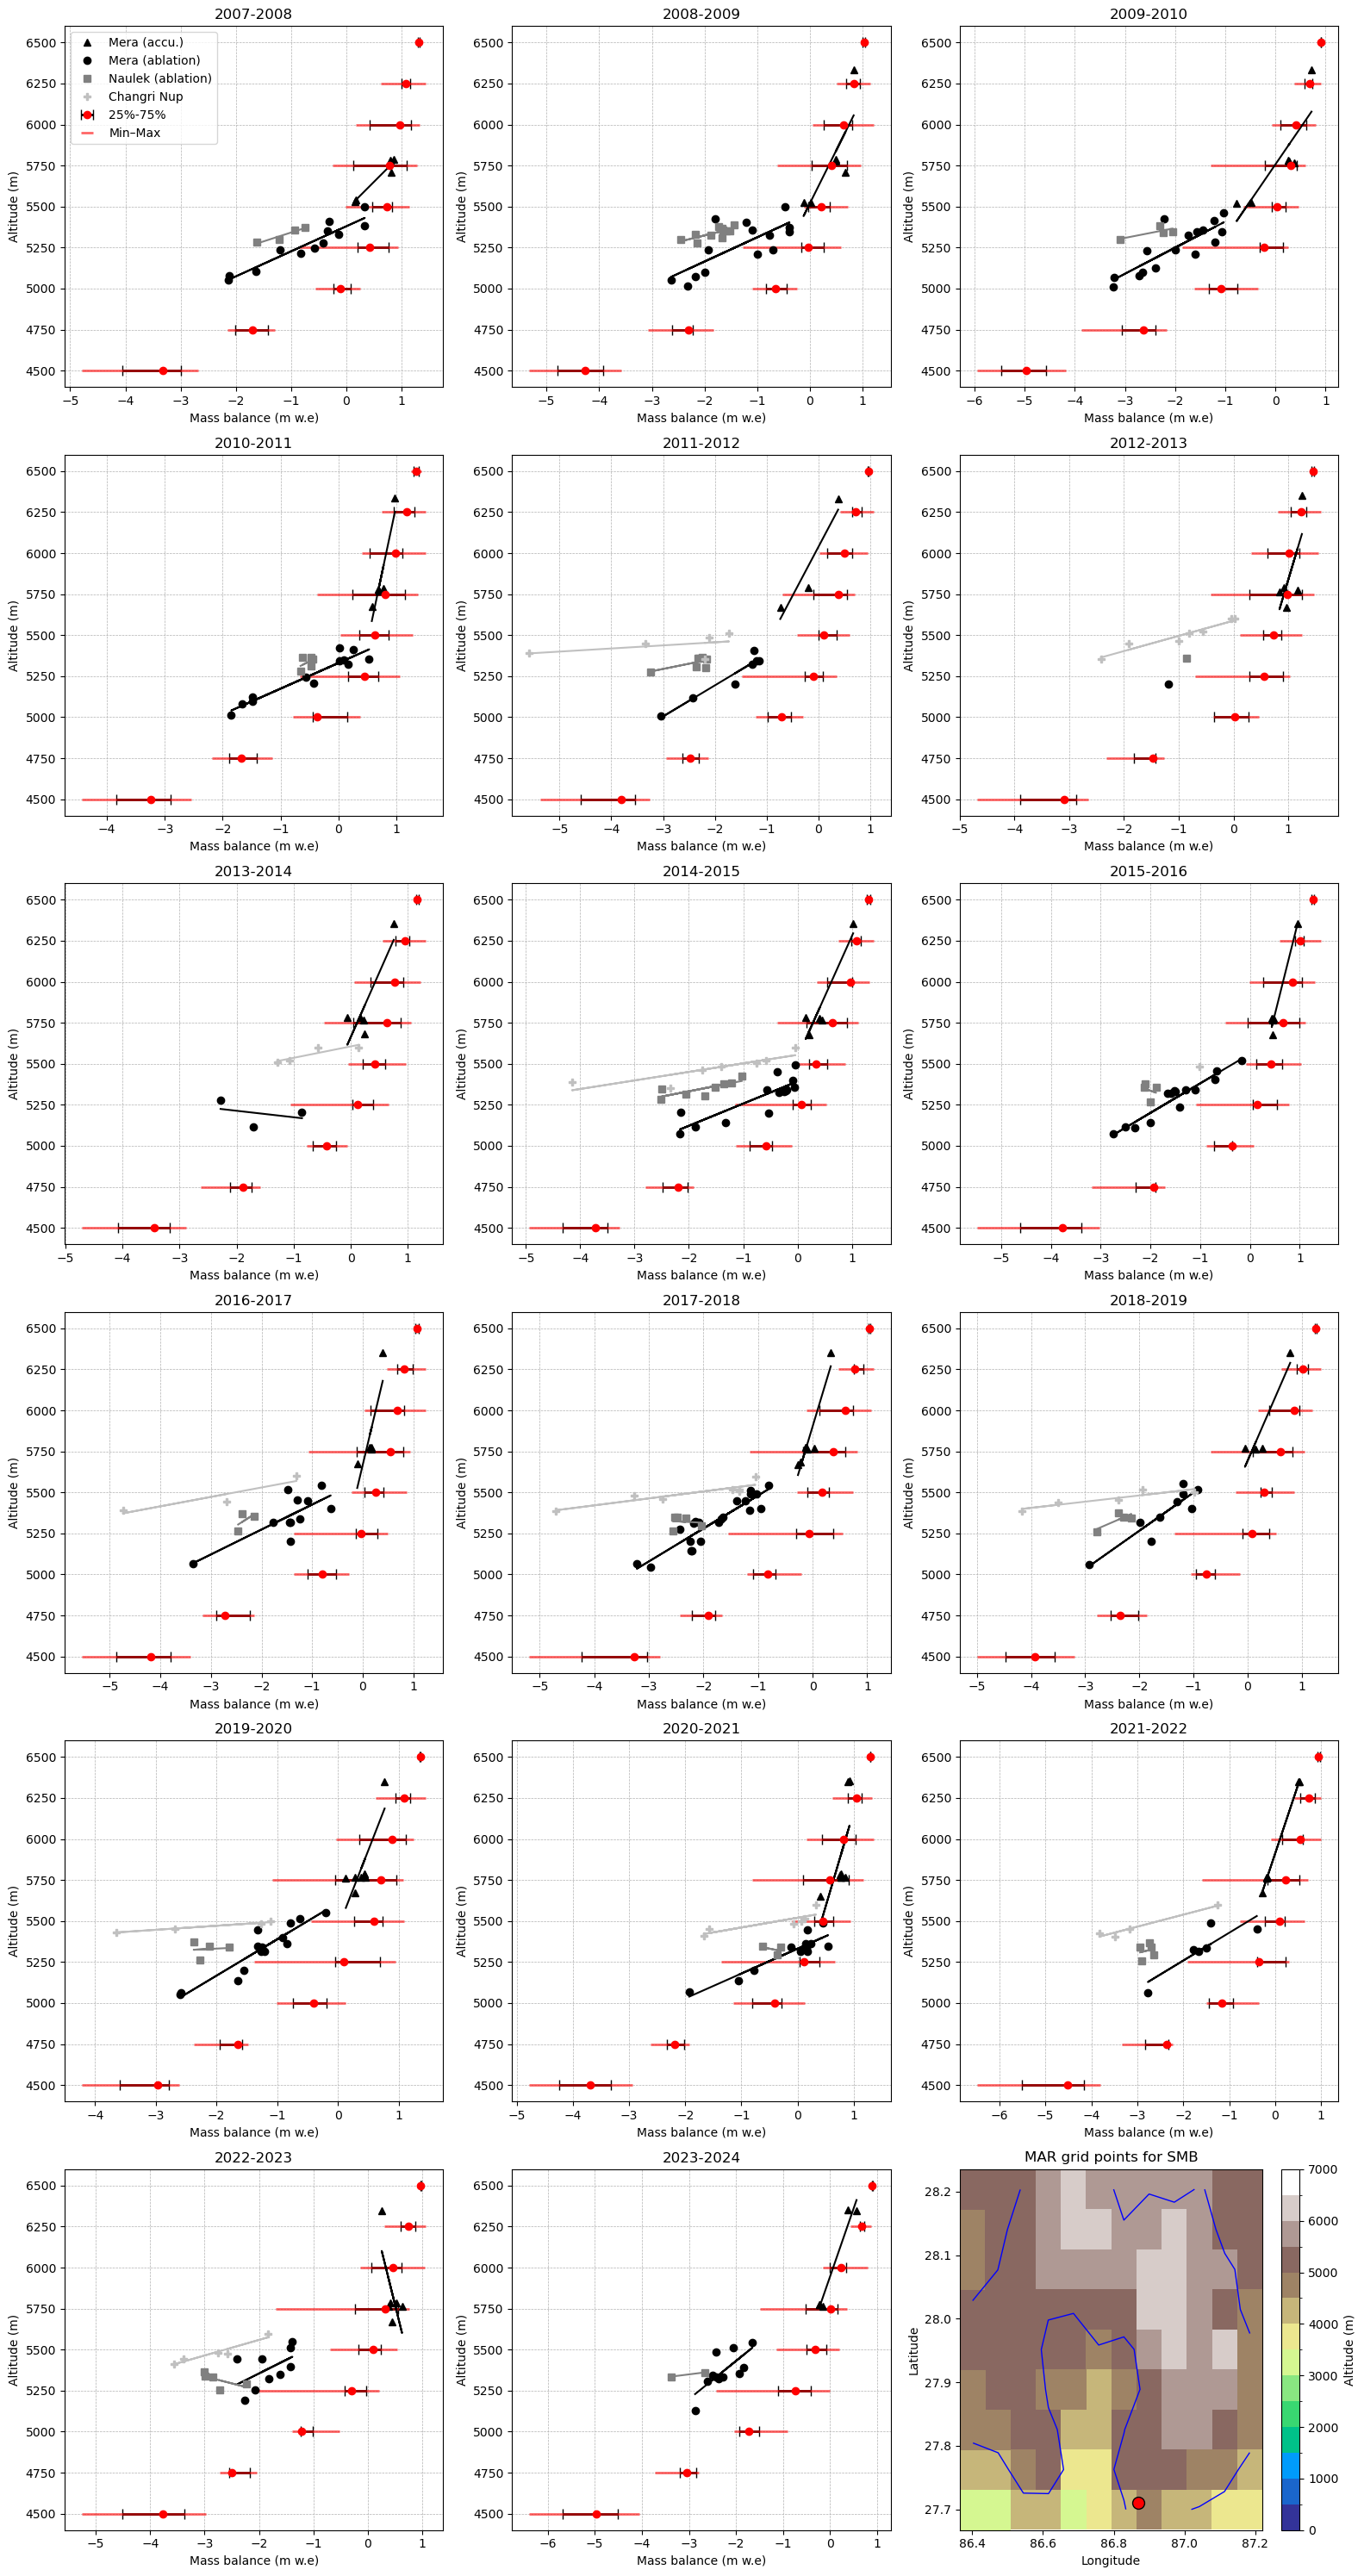

In [16]:
### Khumbu alt band

Ydown, Yup, Xleft, Xright = iY, iY+9, iX-7, iX+5 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))


####### Grid on last subplot ######
ax = axes[nyy]

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")

###### Subplot filling ######
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######    
    SMB_day_khumbu = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten() 

    SH_MAR_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    mask_zero = SMB_MAR_khumbu != 0 # Masque les valeurs=0 qui ont pu être générés par le ice_level
    SMB_MAR_khumbu = SMB_MAR_khumbu[mask_zero]
    SH_MAR_khumbu = SH_MAR_khumbu[mask_zero]

    #### Création des classes d'altitude (pas de 250 m)
    alt_band = np.arange(125, 7000, 250)
    alt_classes = np.digitize(SH_MAR_khumbu, alt_band) # Digitize permet de mettre dans les classes d'altitude les différentes grilles selon leur altitudes sous forme de liste [1,2,2,1,3,2]

    SMB_min, SMB_max, SMB_p50, SMB_p25, SMB_p75, alt_center = [], [], [], [], [], [] # Définition des listes des percentilles, min et max de chaque classe d'alt

    for a in np.unique(alt_classes): # Comme alt_classes est une liste donnant un indice à chaque point de grille en fonction de l'altitude. np.unique ne regarde qu'une fois un indice déjà vu
        # Création d'un mask "m" qui va prendre la forme m = [False, True, True, False...] avec une condition sur si la classe et sur si la valeur de SMB n'est pas nulle
        m = (alt_classes == a) & (SMB_MAR_khumbu != 0) 

        smbk = SMB_MAR_khumbu[m]
        shk = SH_MAR_khumbu[m]

        if len(smbk) == 0:   # Si la liste smbk pour une classe d'alt est vide (cad que tous les smb pour cette alt sont nuls), on passe à l'itération suivante pour éviter un bug dans la boucle
            continue

        p25 = np.percentile(smbk, 25)
        p50 = np.percentile(smbk, 50)   # médiane
        p75 = np.percentile(smbk, 75)
        
        # Grâce au mask, on peut alors faire des opérations sur les variables restreintes aux bandes d'altitudes
        SMB_p25.append(p25)
        SMB_p50.append(p50)
        SMB_p75.append(p75)
        SMB_min.append(np.min(smbk))
        SMB_max.append(np.max(smbk))
        
        #alt_center.append(np.mean(shk))
        alt_center.append(alt_band[a-1] + 125) # Affiche simplement le centre de la bande sans moyenner ("a-1" car digitize a un indice qui commence par 1)

    SMB_p25 = np.array(SMB_p25) # Transformation des listes en tableaux pour pouvoir les plot
    SMB_p50 = np.array(SMB_p50)
    SMB_p75 = np.array(SMB_p75)
    SMB_min = np.array(SMB_min)
    SMB_max = np.array(SMB_max)
    alt_center = np.array(alt_center)

    # Plot des percentilles avec xerr qui affiche une barre de couleur "ecolor", et de taille "capsize"
    ax.errorbar(SMB_p50, alt_center, xerr=[SMB_p50-SMB_p25, SMB_p75-SMB_p50], fmt="o", color="r", ecolor="k", elinewidth=2, capsize=4, label="25%-75%")

    ax.errorbar(SMB_p50, alt_center, xerr=[SMB_p50-SMB_min, SMB_max-SMB_p50], fmt="none", ecolor="r", elinewidth=2, alpha=0.6, label="Min–Max")
    
    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="^", color='k', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'k') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='k', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], color='k') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="s", color='gray', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'gray') # Naulek ablation regression

    ##### Changri Nup
    ax.plot(SMB_chan[j], SH_chan[j], linestyle="", marker="P", color='silver', label='Changri Nup') # Changri Nup
    
    if reg_chan[j] is not None: # Si on était à une année sans données de chagri on n'affiche pas sa régression linéaire
        ax.plot(SMB_chan[j], reg_chan[j].intercept + reg_chan[j].slope * SMB_chan[j], 'silver') # Changri Nup regression lineaire
      
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()

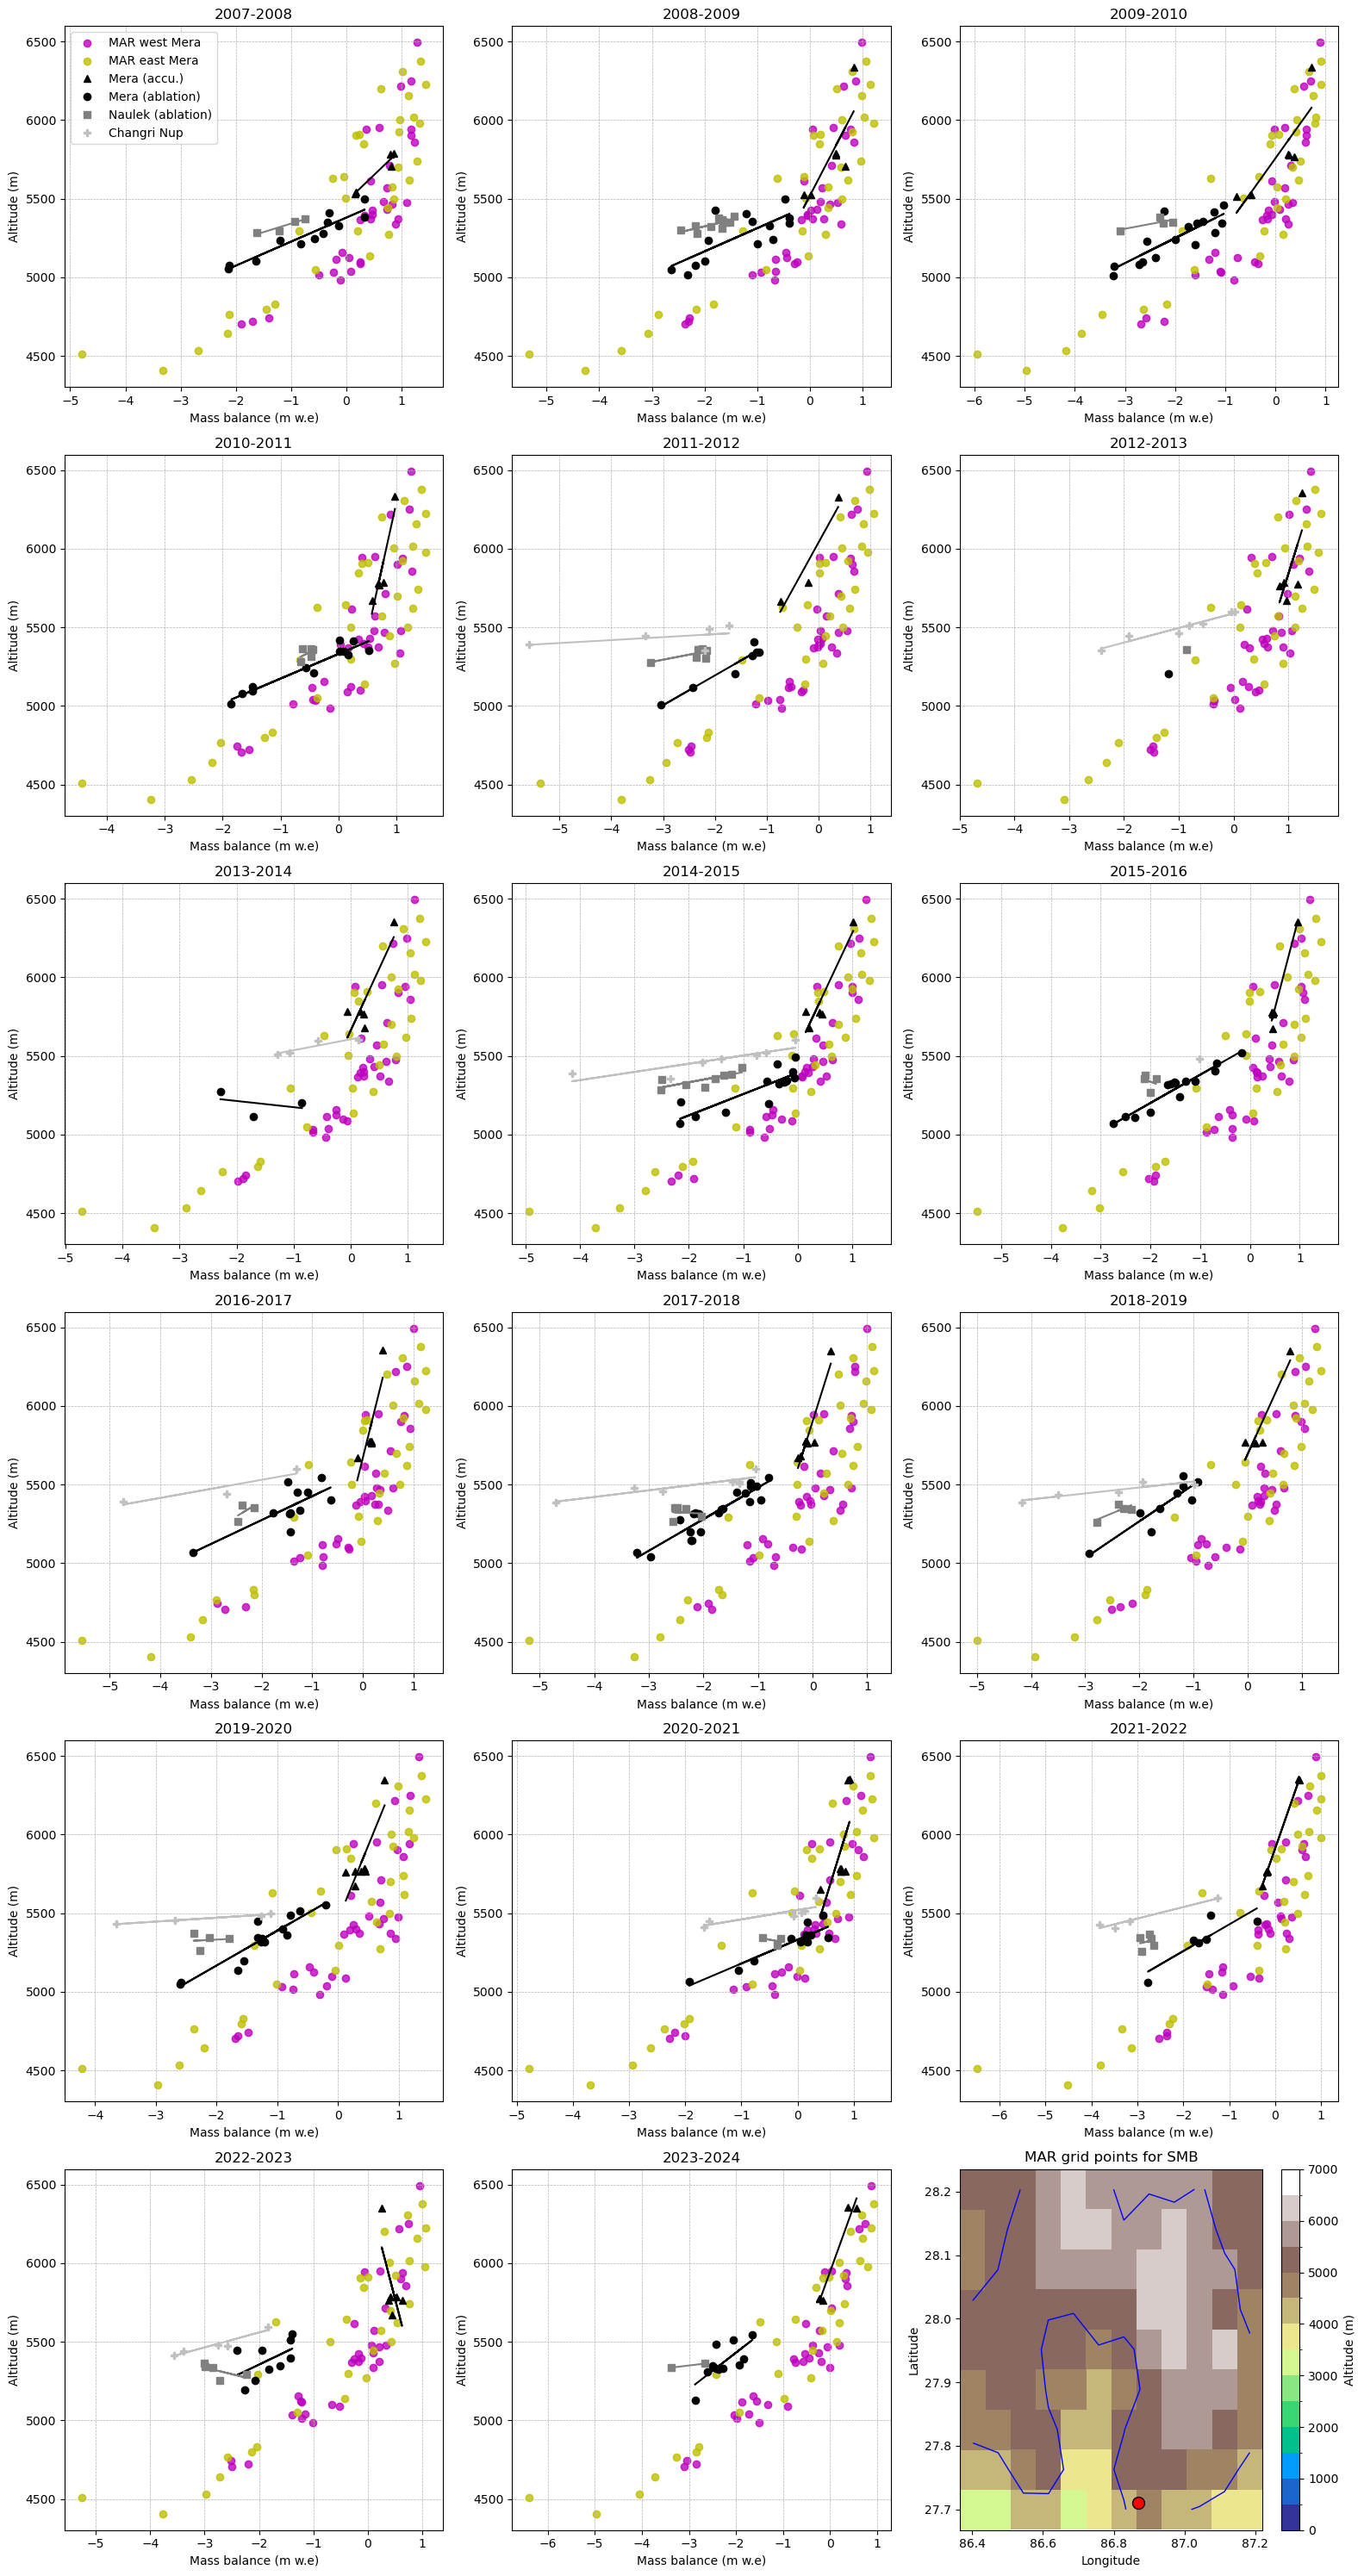

In [17]:
### Khumbu domain east/west

Ydown, Yup, Xleft, Xright = iY, iY+9, iX-7, iX+5 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))

SMB_khumbu_west = []
SMB_khumbu_east = []

####### Grid on last subplot ######
ax = axes[nyy]

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")


###### Subplot filling ######
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######    
    SMB_day_khumbu = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten() 

    SH_MAR_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    mask_zero = SMB_MAR_khumbu != 0 # Masque les valeurs=0 qui ont pu être générés par le ice_level
    SMB_MAR_khumbu = SMB_MAR_khumbu[mask_zero]
    SH_MAR_khumbu = SH_MAR_khumbu[mask_zero]

    lon_sep = ds_lon_khumbu.values.flatten()[mask_zero] # J'applique aussi le mask au séparateur pour garder deux tableaux de même taille
    # Séparation en deux catégories les sorties de MAR en fonction de leur position par rapport au point de grille du Mera 
    west = lon_sep < merap_lon
    east = lon_sep >= merap_lon
    
    SMB_west = np.mean(SMB_MAR_khumbu[west])
    SMB_east = np.mean(SMB_MAR_khumbu[east])
    SMB_khumbu_west.append(SMB_west)
    SMB_khumbu_east.append(SMB_east)
    
    # plot de la partie ouest et est des sorties MAR
    ax.scatter(SMB_MAR_khumbu[west], SH_MAR_khumbu[west], color="m", label="MAR west Mera", alpha=0.8)
    ax.scatter(SMB_MAR_khumbu[east], SH_MAR_khumbu[east], color="y", label="MAR east Mera", alpha=0.8)
    
    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="^", color='k', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'k') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='k', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], color='k') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="s", color='gray', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'gray') # Naulek ablation regression

    ##### Changri Nup
    ax.plot(SMB_chan[j], SH_chan[j], linestyle="", marker="P", color='silver', label='Changri Nup') # Changri Nup
    
    if reg_chan[j] is not None: # Si on était à une année sans données de chagri on n'affiche pas sa régression linéaire
        ax.plot(SMB_chan[j], reg_chan[j].intercept + reg_chan[j].slope * SMB_chan[j], 'silver') # Changri Nup regression lineaire
  
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()

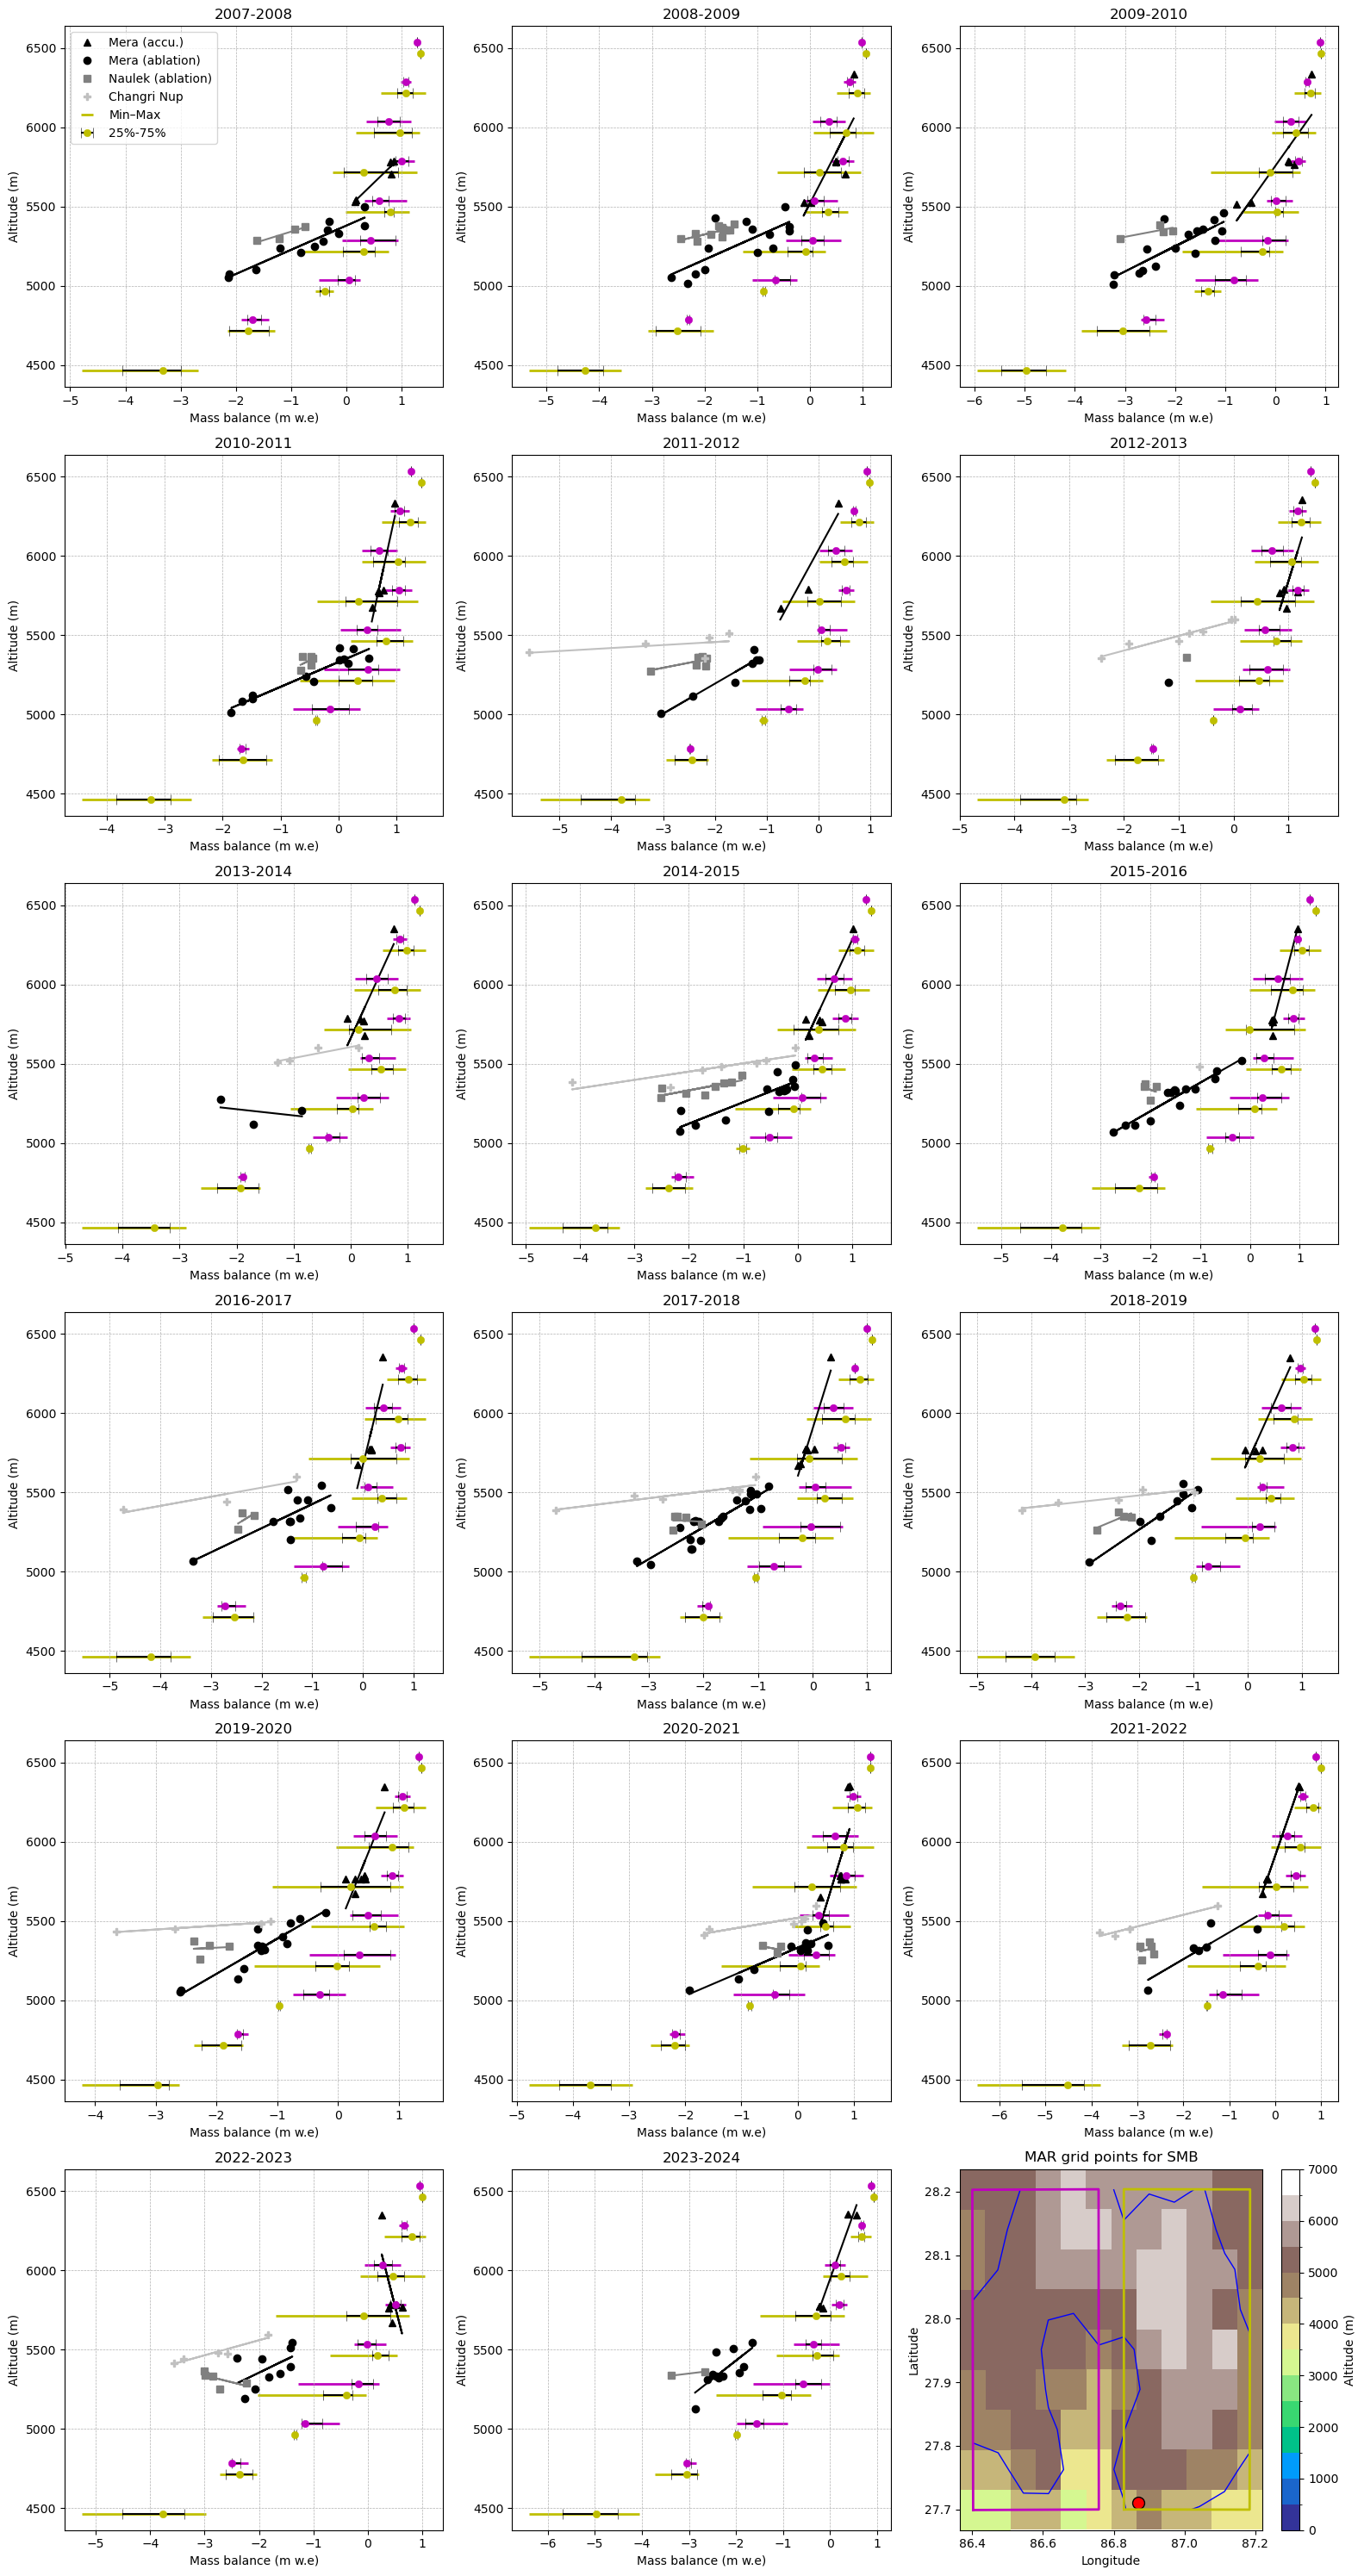

In [18]:
### Khumbu east/west alt band

Ydown, Yup, Xleft, Xright = iY, iY+9, iX-7, iX+5 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))


####### Grid on last subplot ######
ax = axes[nyy]

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")

# Ici on définit des slices sans passer par iY et iX car on a déjà découpé le domaine sur le khumbu
# On cherche des zones dans le khumbu à partir du bas gauche du domaine (sous la forme slice(y,y),slice(x,x) --> Point en bas à gauche est (0,0)
# orange=everest / rouge=procheMera / magenta= NordOuest
subdom = [(slice(0,9), slice(6,12), "y"), (slice(0,9), slice(0,6),"m")]

for ys, xs, color in subdom: # On a un tuple, le nom des variable n'a pas d'importance tant que l'ordre est respecté
    lat_sub = ds_lat_khumbu.isel(y=ys, x=xs).values
    lon_sub = ds_lon_khumbu.isel(y=ys, x=xs).values

    rect_lat = [lat_sub[0,0], lat_sub[0,-1], lat_sub[-1,-1], lat_sub[-1,0], lat_sub[0,0]] # Selection des angles des sous domaines
    rect_lon = [lon_sub[0,0], lon_sub[0,-1], lon_sub[-1,-1], lon_sub[-1,0], lon_sub[0,0]]
    
    ax.plot(rect_lon, rect_lat, color=color, linewidth=2)
    
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")

legend = True # Booléen qui permet d'afficher qu'une seule fois la légende des min/max et percentils

###### Subplot filling ######
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######    
    SMB_day_khumbu = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten() 

    SH_MAR_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    mask_zero = SMB_MAR_khumbu != 0 # Masque les valeurs=0 qui ont pu être générés par le ice_level
    SMB_MAR_khumbu = SMB_MAR_khumbu[mask_zero]
    SH_MAR_khumbu = SH_MAR_khumbu[mask_zero]

    for ys, xs, color in subdom: # On a un tuple, le nom des variable n'a pas d'importance tant que l'ordre est respecté

        SMB_subdom = SMB_sum_khumbu.isel(Y=ys, X=xs).values.flatten()
        SH_subdom  = ds_SH_khumbu.isel(y=ys, x=xs).values.flatten()

        #ax.scatter(SMB_subdom, SH_subdom, color=color, label='MAR')
    
        #### Création des classes d'altitude (pas de 250 m)
        alt_band = np.arange(125, 7000, 250)
        alt_classes = np.digitize(SH_subdom, alt_band) # Digitize permet de mettre dans les classes d'altitude les différentes grilles selon leur altitudes sous forme de liste [1,2,2,1,3,2]

        SMB_min, SMB_max, SMB_p50, SMB_p25, SMB_p75, alt_center = [], [], [], [], [], [] # Définition des listes des percentilles, min et max de chaque classe d'alt

        for a in np.unique(alt_classes): # Comme alt_classes est une liste donnant un indice à chaque point de grille en fonction de l'altitude. np.unique ne regarde qu'une fois un indice déjà vu
            # Création d'un mask "m" qui va prendre la forme m = [False, True, True, False...] avec une condition sur si la classe et sur si la valeur de SMB n'est pas nulle
            m = (alt_classes == a) & (SMB_subdom != 0) 

            smbk = SMB_subdom[m]
            shk = SH_subdom[m]

            if len(smbk) == 0:   # Si la liste smbk pour une classe d'alt est vide (cad que tous les smb pour cette alt sont nuls), on passe à l'itération suivante pour éviter un bug dans la boucle
                continue

            p25 = np.percentile(smbk, 25)
            p50 = np.percentile(smbk, 50)   # médiane
            p75 = np.percentile(smbk, 75)
        
            # Grâce au mask, on peut alors faire des opérations sur les variables restreintes aux bandes d'altitudes
            SMB_p25.append(p25)
            SMB_p50.append(p50)
            SMB_p75.append(p75)
            SMB_min.append(np.min(smbk))
            SMB_max.append(np.max(smbk))
        
            #alt_center.append(np.mean(shk))
            alt_center.append(alt_band[a-1] + 125) # Affiche simplement le centre de la bande sans moyenner ("a-1" car digitize a un indice qui commence par 1)

        SMB_p25 = np.array(SMB_p25) # Transformation des listes en tableaux pour pouvoir les plot
        SMB_p50 = np.array(SMB_p50)
        SMB_p75 = np.array(SMB_p75)
        SMB_min = np.array(SMB_min)
        SMB_max = np.array(SMB_max)
        alt_center = np.array(alt_center)

        offset = {"y": -35, "m": 35} # Rajoute un leger offset de en altitude pour ne pas supperposer les valeurs

        # Plot de la barre d'erreur avec xerr qui affiche une barre de couleur "ecolor", et de taille "capsize"
        ax.errorbar(SMB_p50, alt_center + offset[color], xerr=[SMB_p50-SMB_min, SMB_max-SMB_p50], fmt="none", ecolor=color, elinewidth=2, alpha=1, label="Min–Max" if legend else None, zorder=1) # Condition sur l'affichage de la légende
        ax.errorbar(SMB_p50, alt_center + offset[color], xerr=[SMB_p50-SMB_p25, SMB_p75-SMB_p50], fmt="o", color=color, ecolor='k', elinewidth=1.5, capsize=4, label="25%-75%" if legend else None, markeredgewidth=0.4, zorder=3)

        legend = False # Booléen qui permet d'afficher qu'une seule fois la légende des min/max et percentils

    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="^", color='k', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'k') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='k', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], color='k') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="s", color='gray', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'gray') # Naulek ablation regression

    ##### Changri Nup
    ax.plot(SMB_chan[j], SH_chan[j], linestyle="", marker="P", color='silver', label='Changri Nup') # Changri Nup
    
    if reg_chan[j] is not None: # Si on était à une année sans données de chagri on n'affiche pas sa régression linéaire
        ax.plot(SMB_chan[j], reg_chan[j].intercept + reg_chan[j].slope * SMB_chan[j], 'silver') # Changri Nup regression lineaire
      
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()
plt.savefig("Mera_east_west.png", dpi=300, bbox_inches="tight")

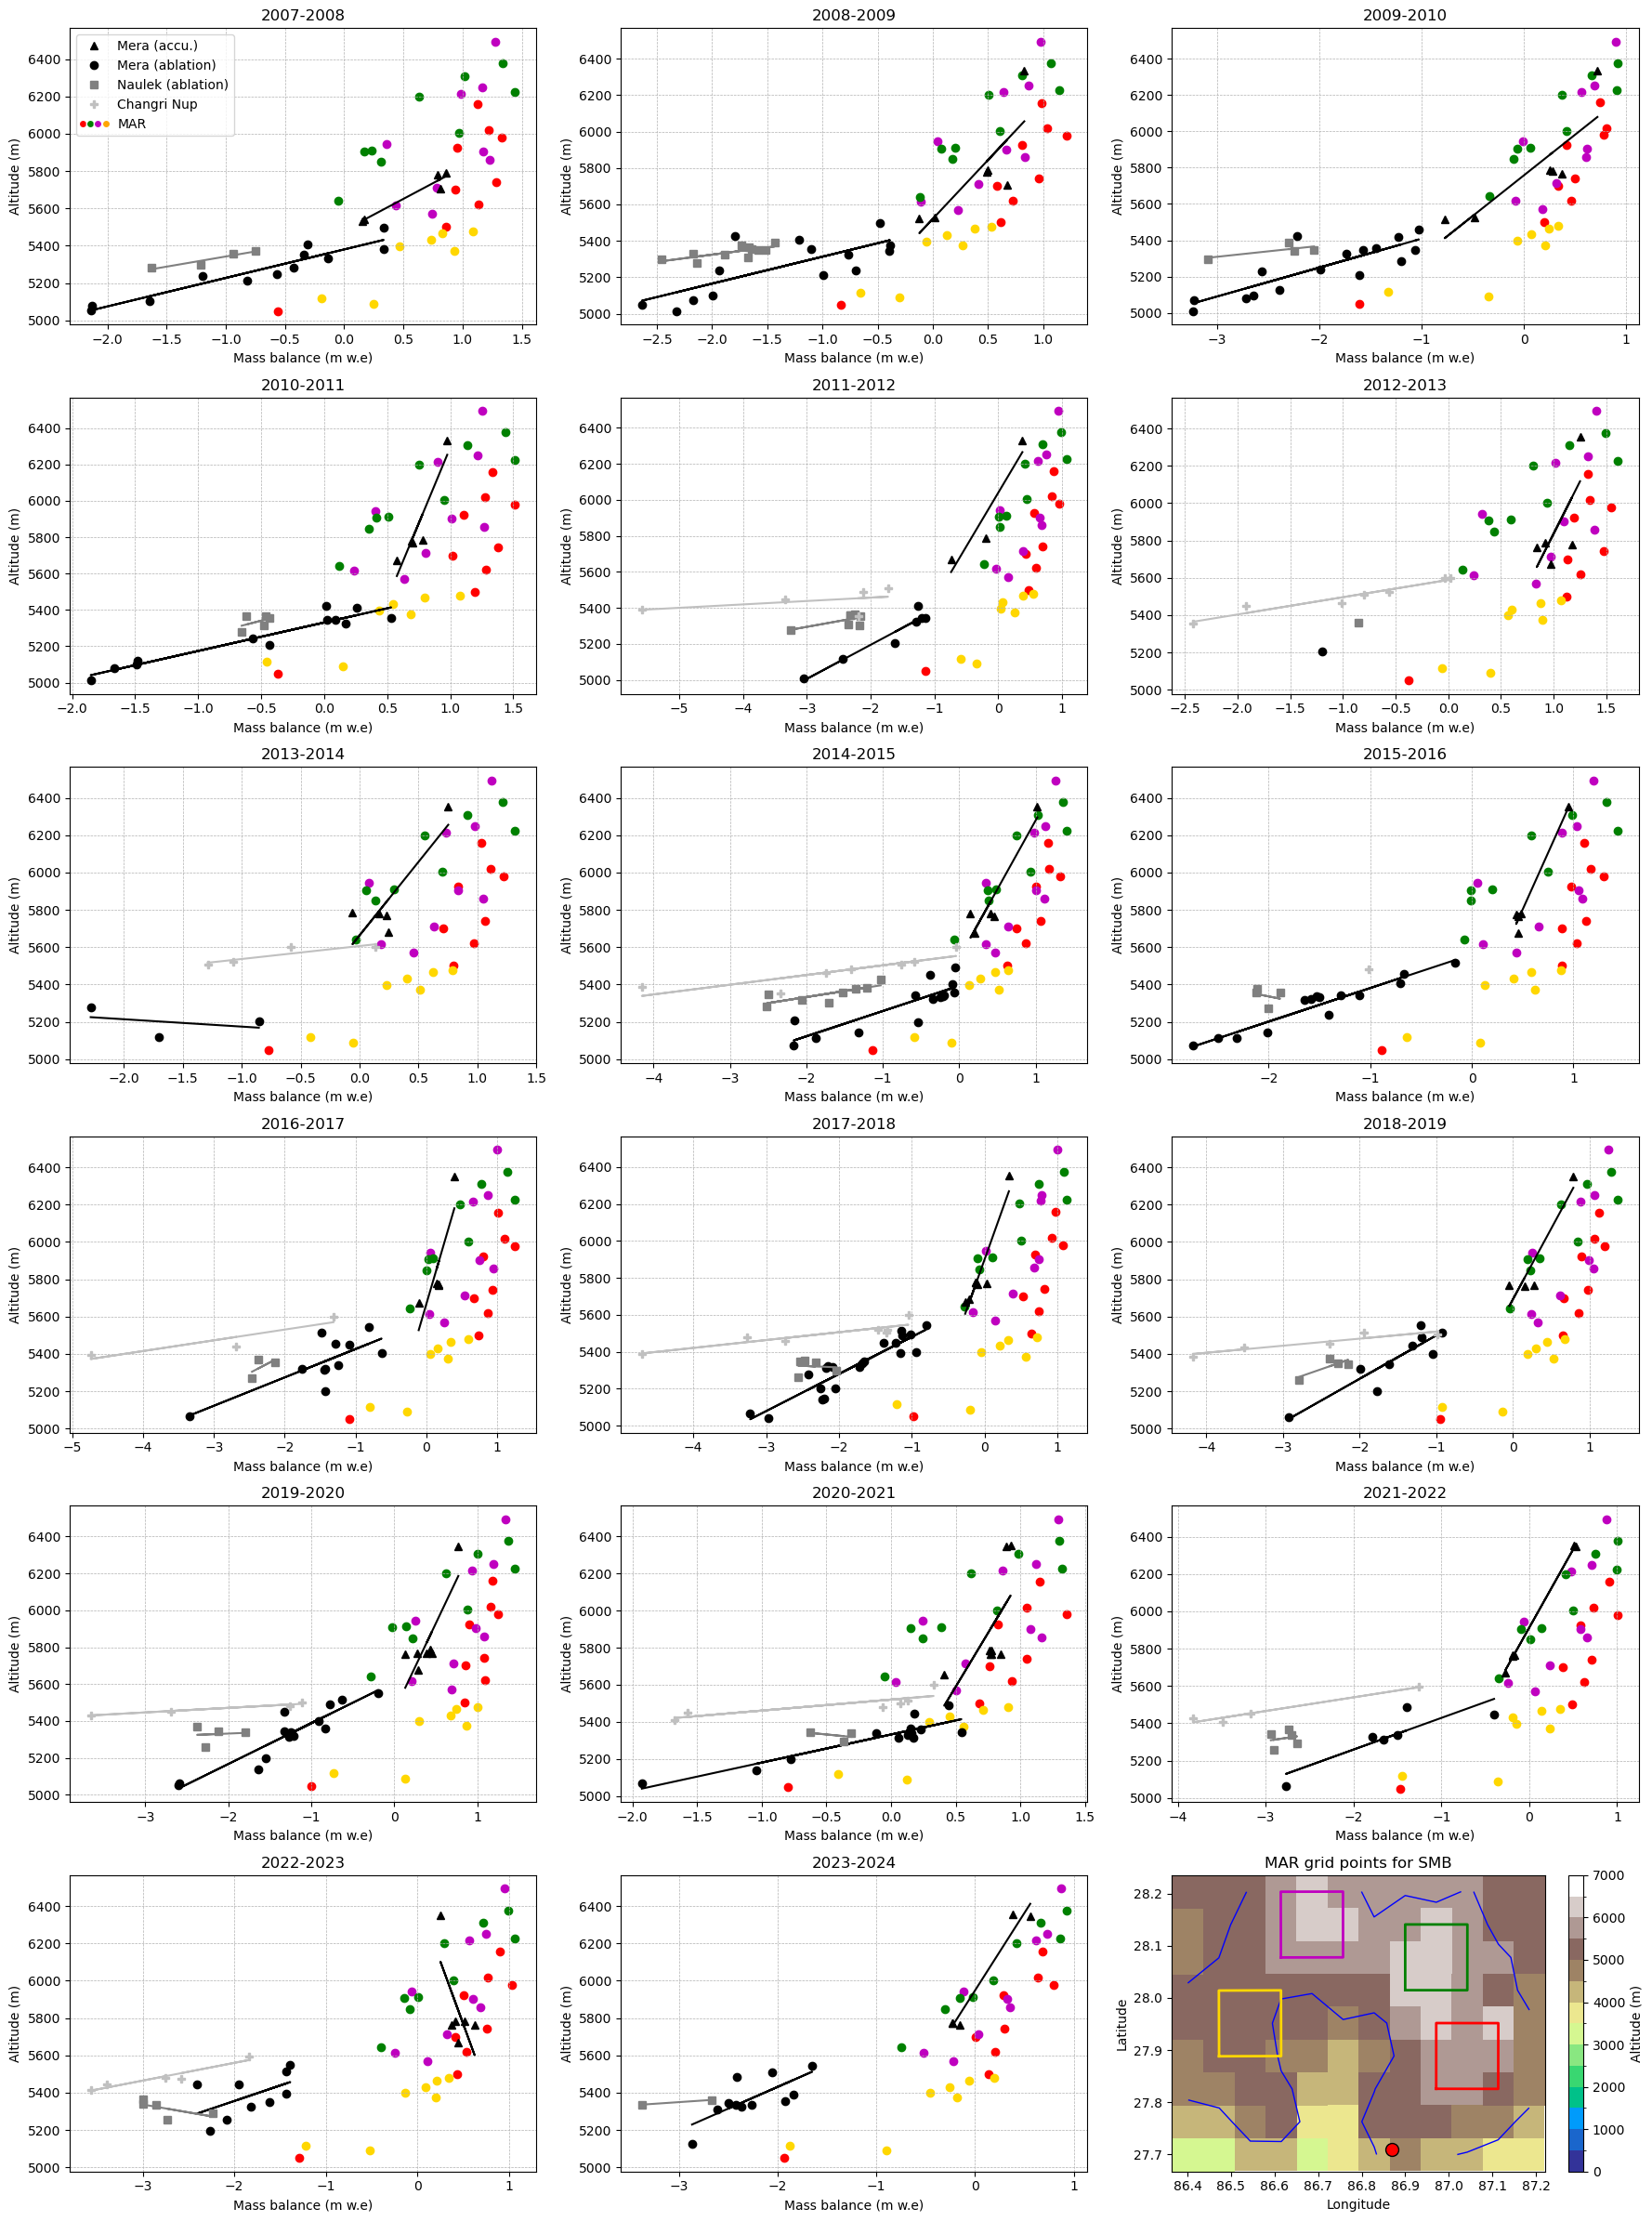

In [19]:
### Khumbu split in 4 domains

Ydown, Yup, Xleft, Xright = iY, iY+9, iX-7, iX+5 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(18,4*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))

SMB_khumbu = {"r": [], "gold": [], "m": [], "g": []} # Création d'un dictionnaire pour gérer les sous domaines par couleurs

####### Grid on last subplot ######
ax = axes[nyy]

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")

# Ici on définit des slices sans passer par iY et iX car on a déjà découpé le domaine sur le khumbu
# On cherche des zones dans le khumbu à partir du bas gauche du domaine (sous la forme slice(y,y),slice(x,x) --> Point en bas à gauche est (0,0)
# orange=everest / rouge=procheMera / magenta= NordOuest
subdom = [(slice(2,5), slice(8,11), "r"), (slice(3,6), slice(1,4),"gold"), (slice(6,9), slice(3,6), "m"), (slice(5,8), slice(7,10), "g")]

for ys, xs, color in subdom: # On a un tuple, le nom des variable n'a pas d'importance tant que l'ordre est respecté
    lat_sub = ds_lat_khumbu.isel(y=ys, x=xs).values
    lon_sub = ds_lon_khumbu.isel(y=ys, x=xs).values

    rect_lat = [lat_sub[0,0], lat_sub[0,-1], lat_sub[-1,-1], lat_sub[-1,0], lat_sub[0,0]] # Selection des angles des sous domaines
    rect_lon = [lon_sub[0,0], lon_sub[0,-1], lon_sub[-1,-1], lon_sub[-1,0], lon_sub[0,0]]
    
    ax.plot(rect_lon, rect_lat, color=color, linewidth=2)
    
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")

###### Subplot filling ######
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######    
    SMB_day_khumbu = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres

    for ys, xs, color in subdom: # On a un tuple, le nom des variable n'a pas d'importance tant que l'ordre est respecté

        SMB_subdom = SMB_sum_khumbu.isel(Y=ys, X=xs).values.flatten()
        SH_subdom  = ds_SH_khumbu.isel(y=ys, x=xs).values.flatten()

        mask_zero = SMB_subdom != 0 # Masque les valeurs=0 qui ont pu être générés par le ice_level
        SMB_subdom = SMB_subdom[mask_zero]
        SH_subdom = SH_subdom[mask_zero]

        # Préparation des listes pour plot séries temporelles
        smbk = SMB_subdom[SMB_subdom != 0] # Exclusion des SMB égales à zéro
        SMB_khumbu[color].append(np.mean(smbk)) # Ajout de la moyenne du sous domaine par année

        ax.scatter(SMB_subdom, SH_subdom, color=color)   
        
    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="^", color='k', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'k') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='k', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], color='k') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="s", color='gray', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'gray') # Naulek ablation regression

    ##### Changri Nup
    ax.plot(SMB_chan[j], SH_chan[j], linestyle="", marker="P", color='silver', label='Changri Nup') # Changri Nup
    
    if reg_chan[j] is not None: # Si on était à une année sans données de chagri on n'affiche pas sa régression linéaire
        ax.plot(SMB_chan[j], reg_chan[j].intercept + reg_chan[j].slope * SMB_chan[j], 'silver') # Changri Nup regression lineaire
      
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        handles, labels = ax.get_legend_handles_labels() # Affichage d'un point MAR en légende, sous une seule ligne et permet de récupérer les autres légendes
        mar_handle = (Line2D([0], [0], marker='o', color='w', markerfacecolor='r'), Line2D([0], [0], marker='o', color='w', markerfacecolor='g'), Line2D([0], [0], marker='o', color='w', markerfacecolor='m'), Line2D([0], [0], marker='o', color='w', markerfacecolor='orange'),)
        
        handles.append(mar_handle)
        labels.append("MAR")

        ax.legend(handles, labels, handler_map={tuple: HandlerTuple(ndivide=None)}) # Trace sur une ligne les points en les mettant dans un tuple
plt.tight_layout()
#plt.savefig("Mera_subdom.png", dpi=300, bbox_inches="tight")

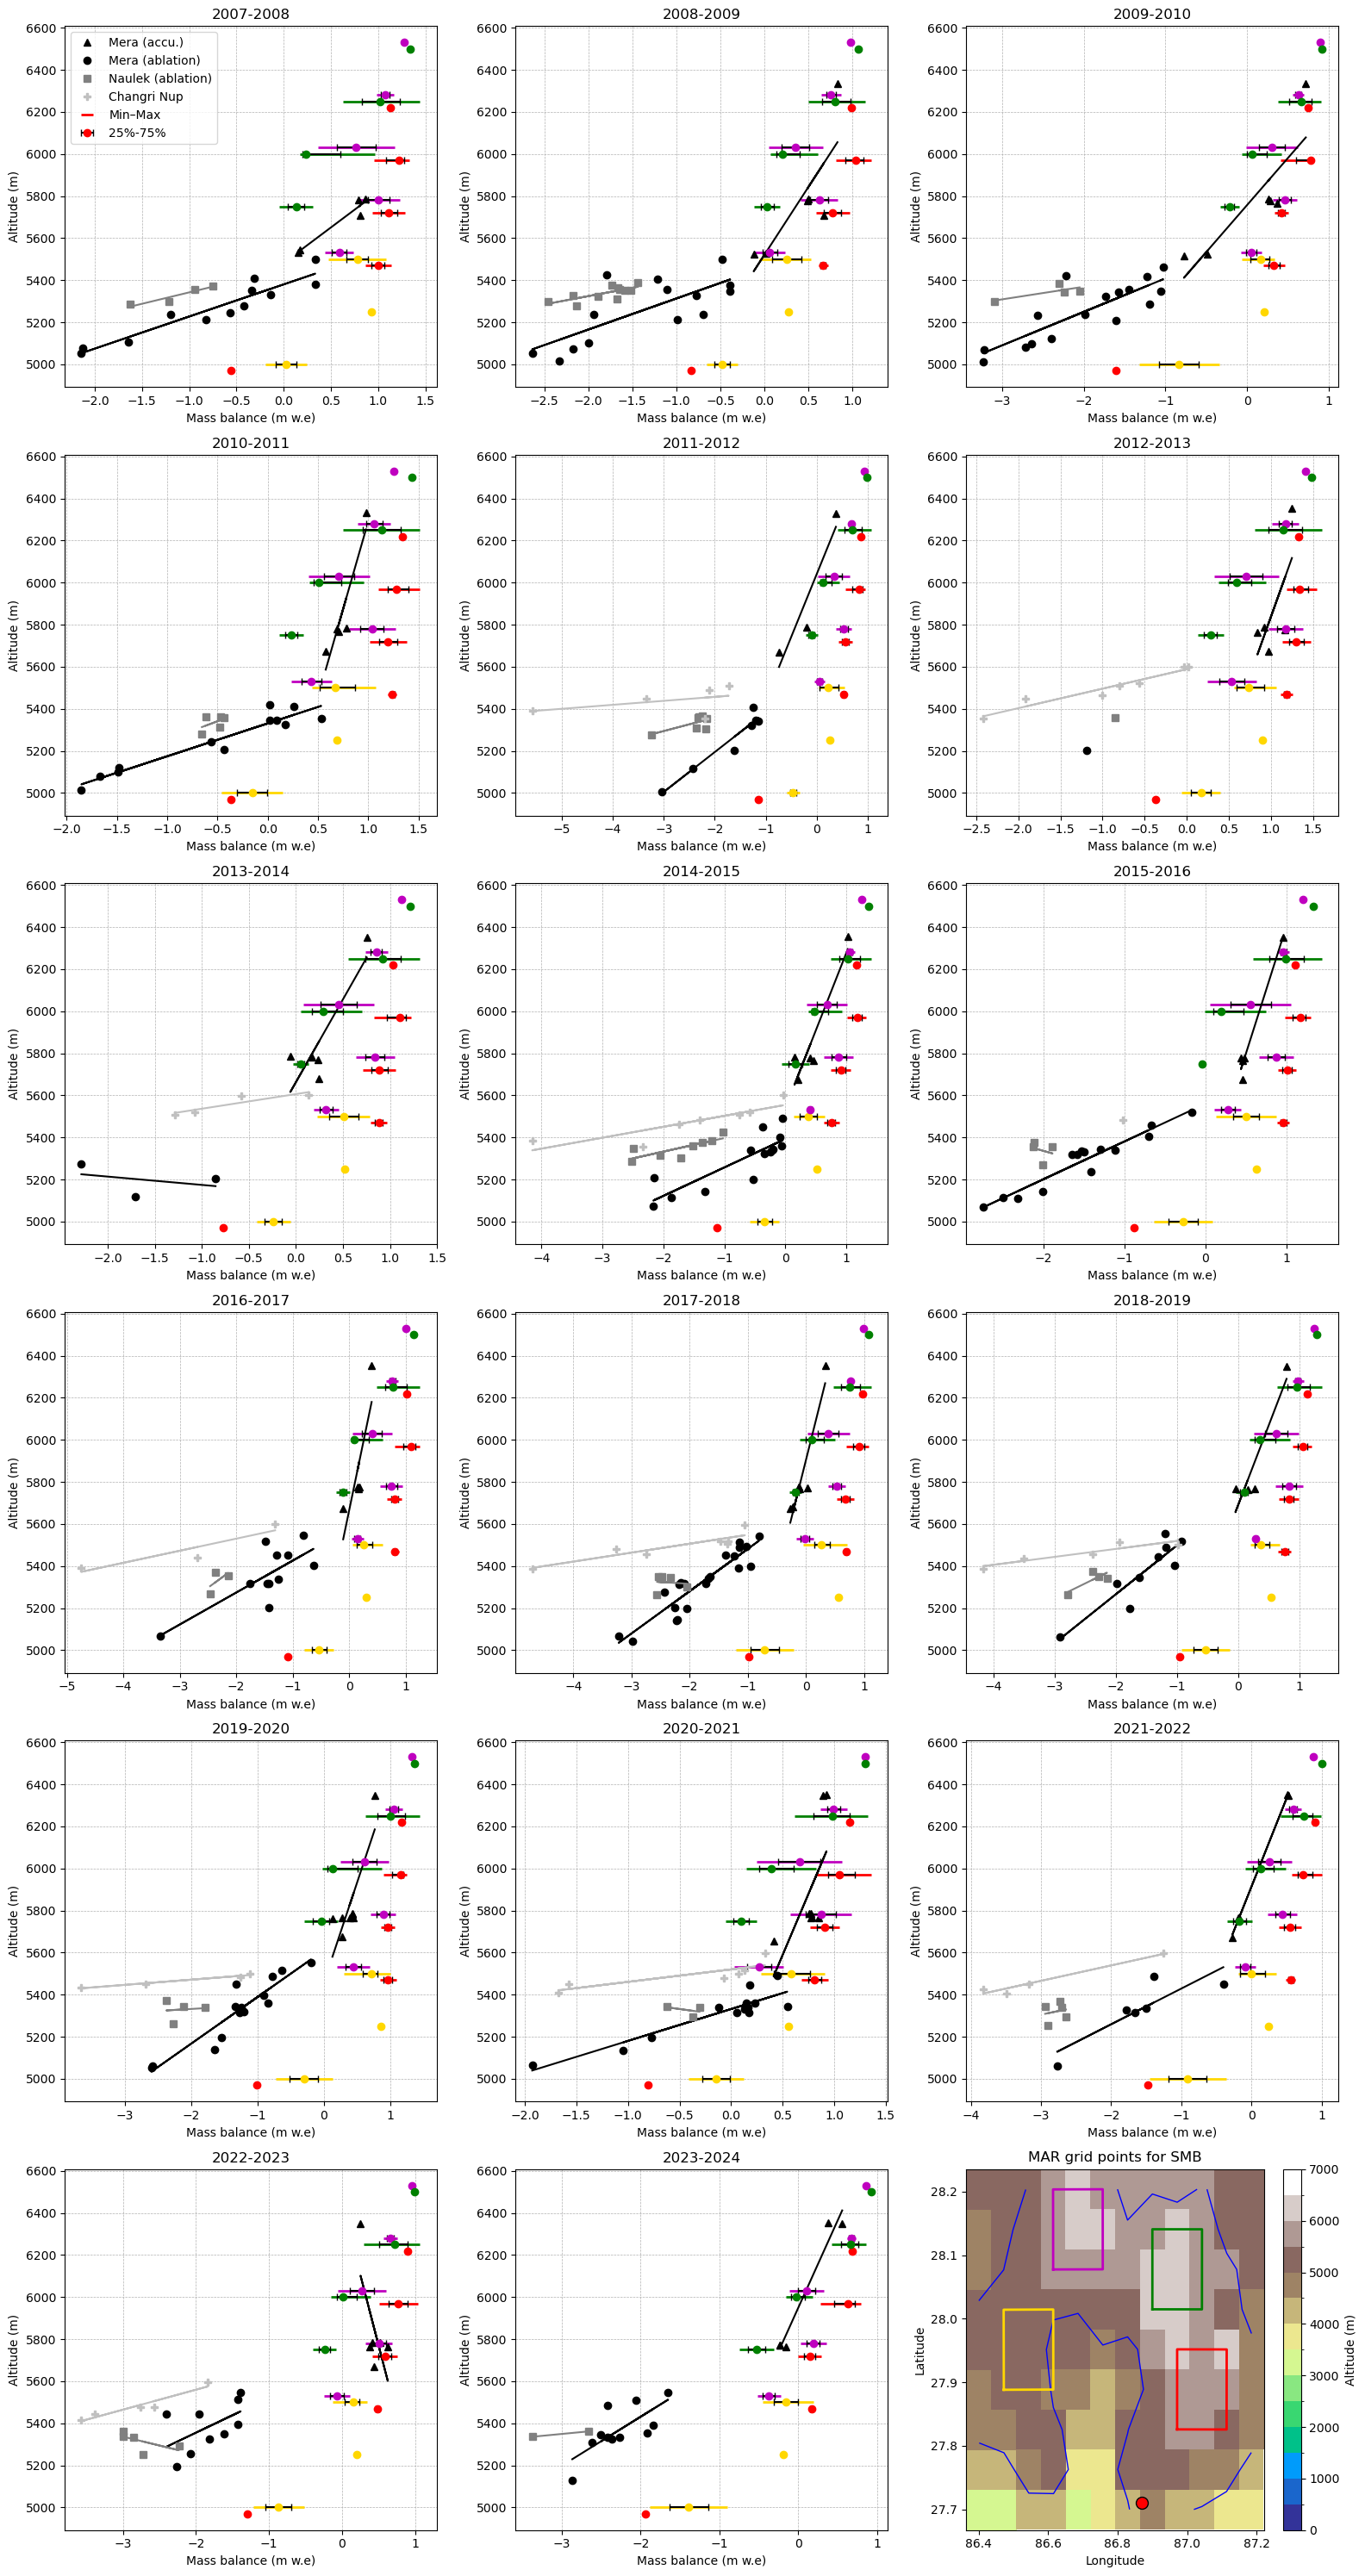

In [20]:
### Khumbu alt band split in 4 domains

Ydown, Yup, Xleft, Xright = iY, iY+9, iX-7, iX+5 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))


####### Grid on last subplot ######
ax = axes[nyy]

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")

# Ici on définit des slices sans passer par iY et iX car on a déjà découpé le domaine sur le khumbu
# On cherche des zones dans le khumbu à partir du bas gauche du domaine (sous la forme slice(y,y),slice(x,x) --> Point en bas à gauche est (0,0)
# orange=everest / rouge=procheMera / magenta= NordOuest
subdom = [(slice(2,5), slice(8,11), "r"), (slice(3,6), slice(1,4),"gold"), (slice(6,9), slice(3,6), "m"), (slice(5,8), slice(7,10), "g")]

for ys, xs, color in subdom: # On a un tuple, le nom des variable n'a pas d'importance tant que l'ordre est respecté
    lat_sub = ds_lat_khumbu.isel(y=ys, x=xs).values
    lon_sub = ds_lon_khumbu.isel(y=ys, x=xs).values

    rect_lat = [lat_sub[0,0], lat_sub[0,-1], lat_sub[-1,-1], lat_sub[-1,0], lat_sub[0,0]] # Selection des angles des sous domaines
    rect_lon = [lon_sub[0,0], lon_sub[0,-1], lon_sub[-1,-1], lon_sub[-1,0], lon_sub[0,0]]
    
    ax.plot(rect_lon, rect_lat, color=color, linewidth=2)
    
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")

legend = True # Booléen qui permet d'afficher qu'une seule fois la légende des min/max et percentils

###### Subplot filling ######
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######    
    SMB_day_khumbu = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten() 

    SH_MAR_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    for ys, xs, color in subdom: # On a un tuple, le nom des variable n'a pas d'importance tant que l'ordre est respecté

        SMB_subdom = SMB_sum_khumbu.isel(Y=ys, X=xs).values.flatten()
        SH_subdom  = ds_SH_khumbu.isel(y=ys, x=xs).values.flatten()

        mask_zero = SMB_subdom != 0 # Masque les valeurs=0 qui ont pu être générés par le ice_level
        SMB_subdom = SMB_subdom[mask_zero]
        SH_subdom = SH_subdom[mask_zero]
        
        #### Création des classes d'altitude (pas de 250 m)
        alt_band = np.arange(125, 7000, 250)
        alt_classes = np.digitize(SH_subdom, alt_band) # Digitize permet de mettre dans les classes d'altitude les différentes grilles selon leur altitudes sous forme de liste [1,2,2,1,3,2]
        
        SMB_min, SMB_max, SMB_p50, SMB_p25, SMB_p75, alt_center = [], [], [], [], [], [] # Définition des listes des percentilles, min et max de chaque classe d'alt

        for a in np.unique(alt_classes): # Comme alt_classes est une liste donnant un indice à chaque point de grille en fonction de l'altitude. np.unique ne regarde qu'une fois un indice déjà vu
            # Création d'un mask "m" qui va prendre la forme m = [False, True, True, False...] avec une condition sur si la classe et sur si la valeur de SMB n'est pas nulle
            m = (alt_classes == a) & (SMB_subdom != 0) 

            smbk = SMB_subdom[m]
            shk = SH_subdom[m]

            if len(smbk) == 0:   # Si la liste smbk pour une classe d'alt est vide (cad que tous les smb pour cette alt sont nuls), on passe à l'itération suivante pour éviter un bug dans la boucle
                continue

            p25 = np.percentile(smbk, 25)
            p50 = np.percentile(smbk, 50)   # médiane
            p75 = np.percentile(smbk, 75)
        
            # Grâce au mask, on peut alors faire des opérations sur les variables restreintes aux bandes d'altitudes
            SMB_p25.append(p25)
            SMB_p50.append(p50)
            SMB_p75.append(p75)
            SMB_min.append(np.min(smbk))
            SMB_max.append(np.max(smbk))
        
            #alt_center.append(np.mean(shk))
            alt_center.append(alt_band[a-1] + 125) # Affiche simplement le centre de la bande sans moyenner ("a-1" car digitize a un indice qui commence par 1)

        SMB_p25 = np.array(SMB_p25) # Transformation des listes en tableaux pour pouvoir les plot
        SMB_p50 = np.array(SMB_p50)
        SMB_p75 = np.array(SMB_p75)
        SMB_min = np.array(SMB_min)
        SMB_max = np.array(SMB_max)
        alt_center = np.array(alt_center)

        offset = {"r": -30, "g": 0, "gold": 0, "m": 30} # Rajoute un leger offset de en altitude pour ne pas supperposer les valeurs

        # Plot de la barre d'erreur avec xerr qui affiche une barre de couleur "ecolor", et de taille "capsize"
        ax.errorbar(SMB_p50, alt_center + offset[color], xerr=[SMB_p50-SMB_min, SMB_max-SMB_p50], fmt="none", ecolor=color, elinewidth=2, alpha=1, label="Min–Max" if legend else None) # Condition sur l'affichage de la légende
        ax.errorbar(SMB_p50, alt_center + offset[color], xerr=[SMB_p50-SMB_p25, SMB_p75-SMB_p50], fmt="o", color=color, ecolor='k', elinewidth=1.5, capsize=3, label="25%-75%" if legend else None)

        legend = False # Booléen qui permet d'afficher qu'une seule fois la légende des min/max et percentils
        
    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="^", color='k', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'k') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='k', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], color='k') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="s", color='gray', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'gray') # Naulek ablation regression

    ##### Changri Nup
    ax.plot(SMB_chan[j], SH_chan[j], linestyle="", marker="P", color='silver', label='Changri Nup') # Changri Nup
    
    if reg_chan[j] is not None: # Si on était à une année sans données de chagri on n'affiche pas sa régression linéaire
        ax.plot(SMB_chan[j], reg_chan[j].intercept + reg_chan[j].slope * SMB_chan[j], 'silver') # Changri Nup regression lineaire
  
    
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()
#plt.savefig("Mera_subdom.png")

In [21]:
#### Manual data loading of Mera and Changri glacier wide MB #####

Mera_MBgw = [0.15, -0.35, -0.75, 0.26, -0.90, 0.19, -0.41, -0.22, -0.42, -0.76, -0.92, -0.80, -0.49, 0.29, -0.85, -0.83, -1.28] # Annual glacier-wide (m w.e.a-1) MB 2007-2020 from Wagnon

error_annual = [0.28, 0.26, 0.24, 0.22, 0.19, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 0.19, 0.22]
error_complet = np.full(len(Mera_MBgw), np.nan) # On rempli par des NaN les valeurs manquantes
error_complet[:len(error_annual)] = error_annual

Mera_MBgw_cum = np.cumsum(Mera_MBgw)

# Remplissage de la liste des années
years = []
for j in range (nyy):
    years.append(int("20"+yy[j+1]))

Changri_MBgw = [-0.95, -1.73, -0.92, -1.33, -1.28, -0.75, -2.56, -2.1, -1.69, -0.83, -0.35, -2.5, -2.65, -2.31]
Changri_MBgw_full = np.full(len(years), np.nan)
start_changri = 2011
start_index = years.index(start_changri)
Changri_MBgw_full[start_index:start_index+len(Changri_MBgw)] = Changri_MBgw
Changri_MBgw_cum = np.nancumsum(Changri_MBgw_full)

n = min(len(years), len(Mera_MBgw)) # Permet de plot jusqu'à ce que la plus petite liste soit vidée

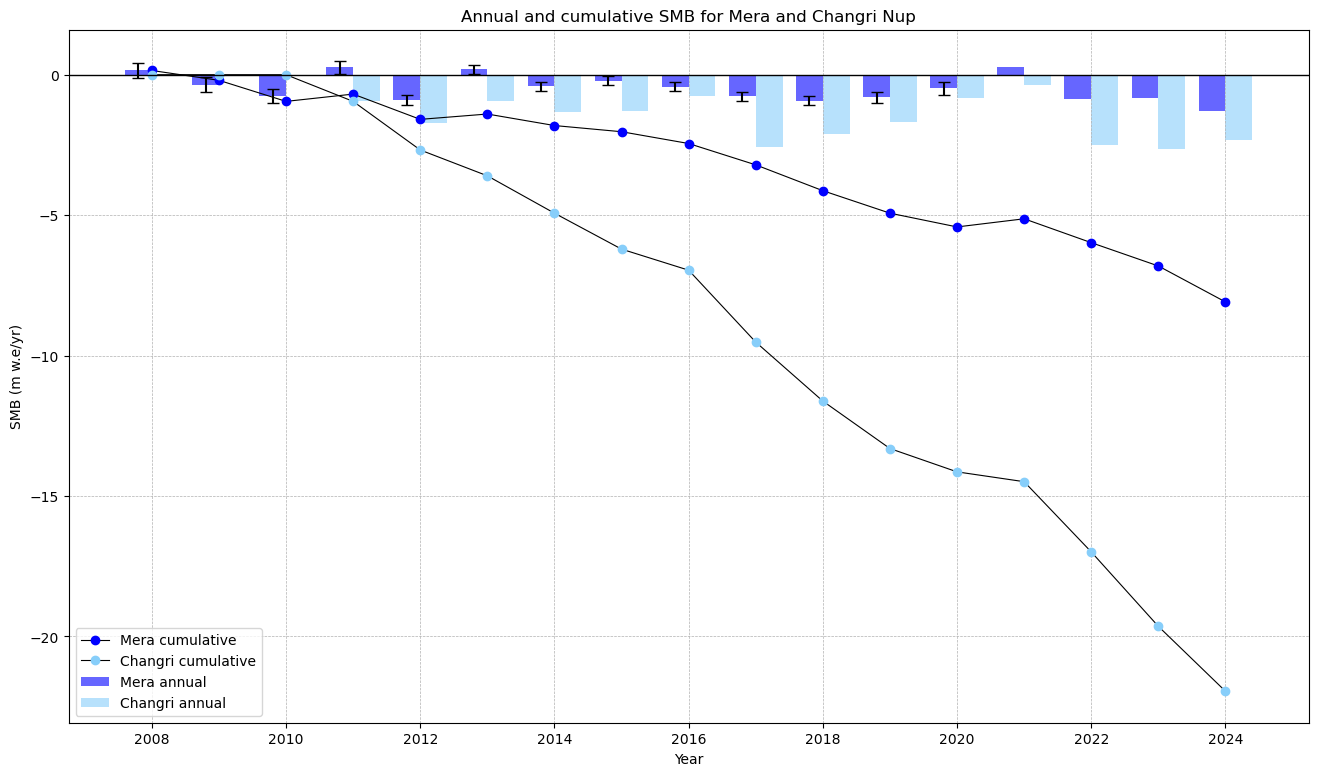

In [22]:
# Série temporelle OBS 
plt.figure(figsize=(16,9))

width = 0.4 # Largeur des barres annual
offsets = [-width/2, width/2] # Décalage des barres annual

series = [("Mera", Mera_MBgw, error_complet, "b"), ("Changri", Changri_MBgw_full, None, "lightskyblue")] # Création de la série contenant les observations

##### Annual ######
for offset, (name, values, err, color) in zip(offsets, series): # Zip permet de parcourir en parallèle offsets et series pour les associer ensemble
    plt.bar(np.array(years[:n]) + offset, values[:n], yerr=err[:n] if err is not None else None, width=width, color=color, alpha=0.6, capsize=4, ecolor='k', label=f"{name} annual") # yerr est une fonction matplotlib qui permet d'afficher les barres d'erreur (si pas de barre d'erreur on passe à la suite)

##### Cumulative ######
##### Mera ######
plt.plot(years[:n], Mera_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="b", markeredgecolor="b", label="Mera cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée
##### Changri #####
plt.plot(years[:n], Changri_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="lightskyblue", markeredgecolor="lightskyblue", label="Changri cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB for Mera and Changri Nup")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.savefig("Changri_timeseries.png")

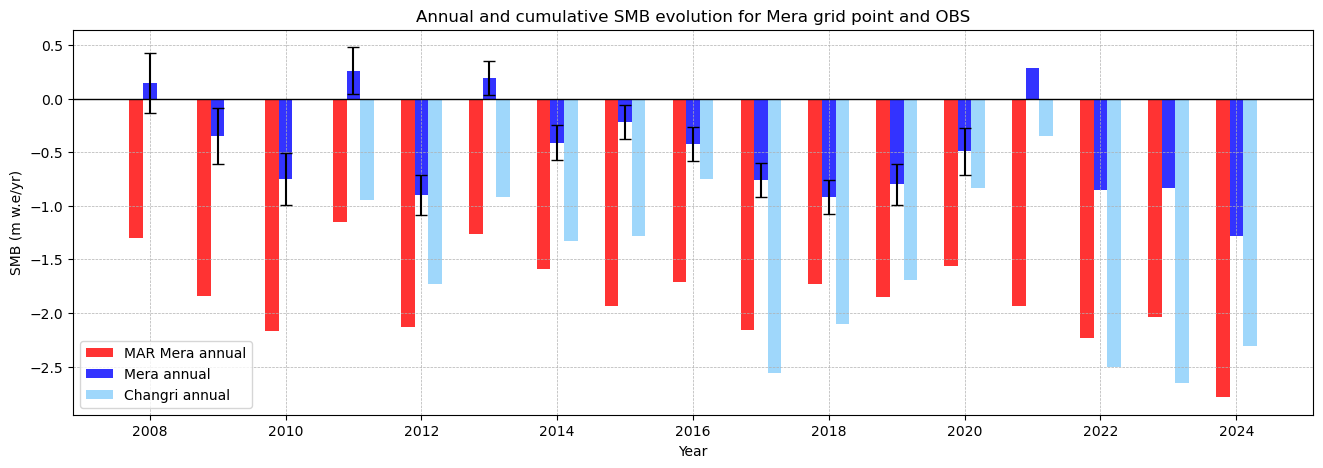

In [23]:
# Série temporelle Mera grid 
plt.figure(figsize=(16,5))

SMB_cum = np.cumsum(SMB_list_Mera)

width = 0.20 # Largeur des barres annual
offsets = [-width, 0, width] # Décalage des barres annual

series = [("MAR Mera", SMB_list_Mera, None, "r"),("Mera", Mera_MBgw, error_complet, "b"), ("Changri", Changri_MBgw_full, None, "lightskyblue")] # Création de la série contenant les observations et MAR

##### Annual ######
for offset, (name, values, err, color) in zip(offsets, series): # Zip permet de parcourir en parallèle offsets et series pour les associer ensemble
    plt.bar(np.array(years[:n]) + offset, values[:n], yerr=err[:n] if err is not None else None, width=width, color=color, alpha=0.8, capsize=4, ecolor='k', label=f"{name} annual") # yerr est une fonction matplotlib qui permet d'afficher les barres d'erreur (si pas de barre d'erreur on passe à la suite)

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB evolution for Mera grid point and OBS")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.savefig("Changri_timeseries.png")

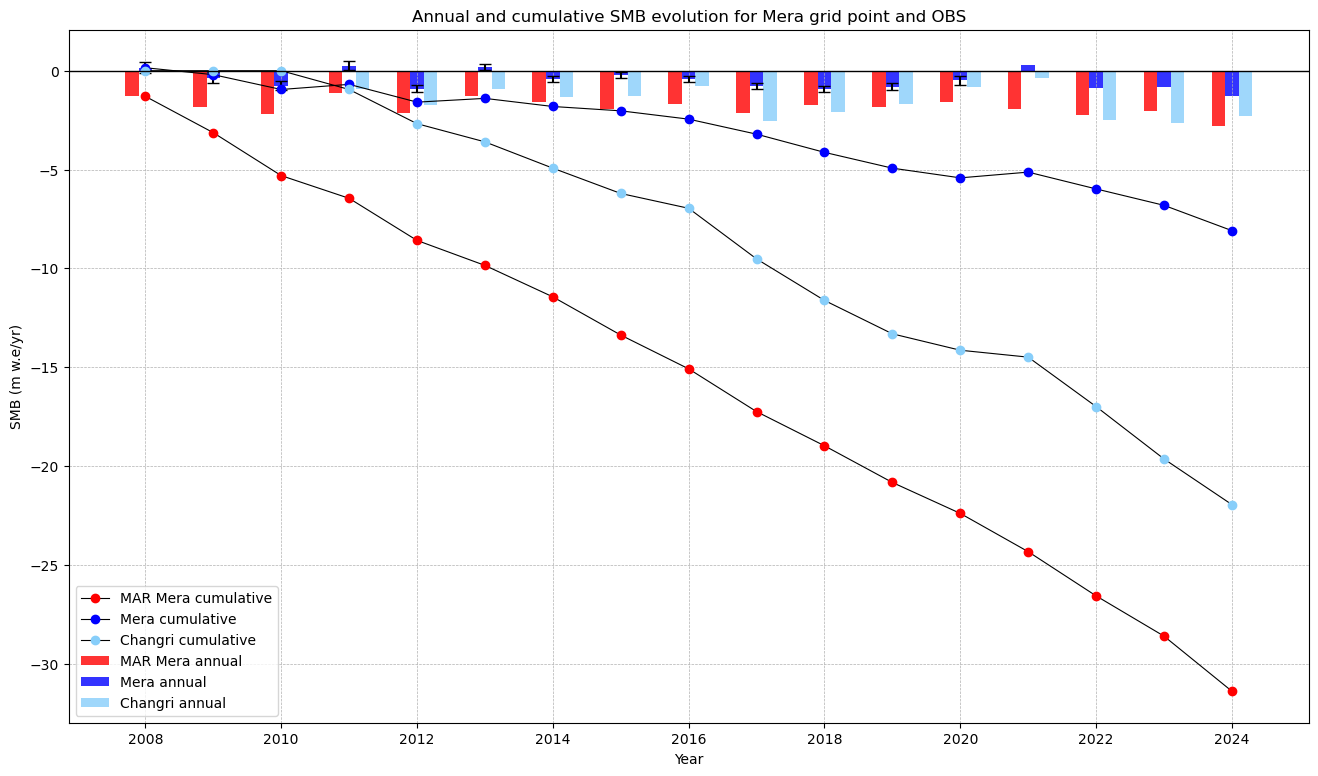

In [24]:
# Série temporelle Mera grid 
plt.figure(figsize=(16,9))

SMB_cum = np.cumsum(SMB_list_Mera)

width = 0.20 # Largeur des barres annual
offsets = [-width, 0, width] # Décalage des barres annual

series = [("MAR Mera", SMB_list_Mera, None, "r"),("Mera", Mera_MBgw, error_complet, "b"), ("Changri", Changri_MBgw_full, None, "lightskyblue")] # Création de la série contenant les observations et MAR

##### Annual ######
for offset, (name, values, err, color) in zip(offsets, series): # Zip permet de parcourir en parallèle offsets et series pour les associer ensemble
    plt.bar(np.array(years[:n]) + offset, values[:n], yerr=err[:n] if err is not None else None, width=width, color=color, alpha=0.8, capsize=4, ecolor='k', label=f"{name} annual") # yerr est une fonction matplotlib qui permet d'afficher les barres d'erreur (si pas de barre d'erreur on passe à la suite)

##### Cumulative ######
##### MAR ######
plt.plot(years, SMB_cum, color="k", linewidth=0.8, marker="o", markerfacecolor="r", markeredgecolor="r", label="MAR Mera cumulative") # Cumulative SMB
##### Mera ######
plt.plot(years[:n], Mera_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="b", markeredgecolor="b", label="Mera cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée
##### Changri #####
plt.plot(years[:n], Changri_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="lightskyblue", markeredgecolor="lightskyblue", label="Changri cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB evolution for Mera grid point and OBS")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.savefig("Changri_timeseries.png")

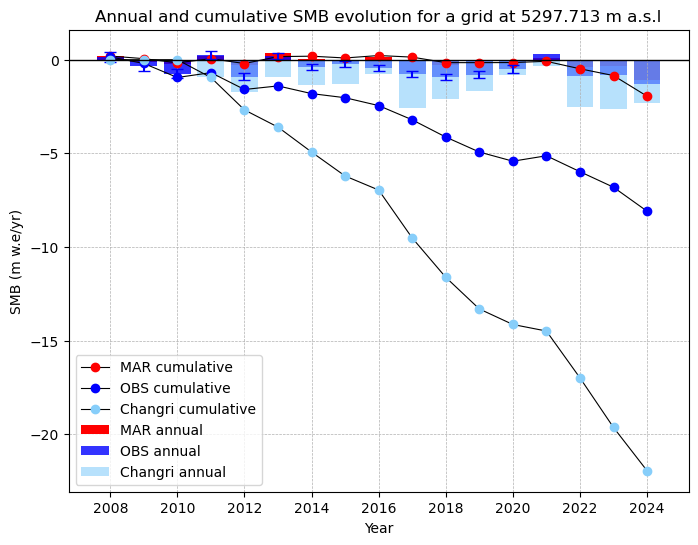

In [25]:
### Série temporelle SMB grille 3 case au nord par rapport au Mera

SMB_list = []
Ygrid, Xgrid = iY+3, iX

for j in range(nyy):
    ###### MAR_data loading and sorting  ######   
    SMB_day = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=Ygrid, X=Xgrid) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum = SMB_day.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR = SMB_sum.values
    SMB_list.append(SMB_MAR)

    SH_MAR = ds_SH.isel(y=Ygrid, x=Xgrid) # Altitude de la grille de MAR au Peak Mera (coord iYN,iXN)
    Grid_alt = SH_MAR.values

plt.figure(figsize=(8,6))

SMB_cum = np.cumsum(SMB_list)

plt.bar(years, SMB_list, color="r", alpha=1, width=0.8, label="MAR annual") # SMB MAR annuel sous forme de bar 
plt.plot(years, SMB_cum, color="k", linewidth=0.8, marker="o", markerfacecolor="r", markeredgecolor="r", label="MAR cumulative") # Cumulative SMB

plt.bar(years[:n], Mera_MBgw[:n], yerr=error_complet[:n],
        color="b", alpha=0.8, width=0.8, capsize=4, ecolor="b", label="OBS annual") # SMB OBS annuel sous forme de bar 
plt.plot(years[:n], Mera_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="b", markeredgecolor="b", label="OBS cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

##### Changri #####
plt.bar(years[:n], Changri_MBgw_full[:n], # yerr est une fonction matplotlib qui permt d'afficher les barres d'erreur 
        color="lightskyblue", alpha=0.6, width=0.8, capsize=4, ecolor="lightskyblue", label="Changri annual") # SMB OBS annuel sous forme de bar 
plt.plot(years[:n], Changri_MBgw_cum[:n], 
         color="k", linewidth=0.8, marker="o", markerfacecolor="lightskyblue", markeredgecolor="lightskyblue", label="Changri cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB evolution for a grid at "+str(Grid_alt)+" m a.s.l")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)


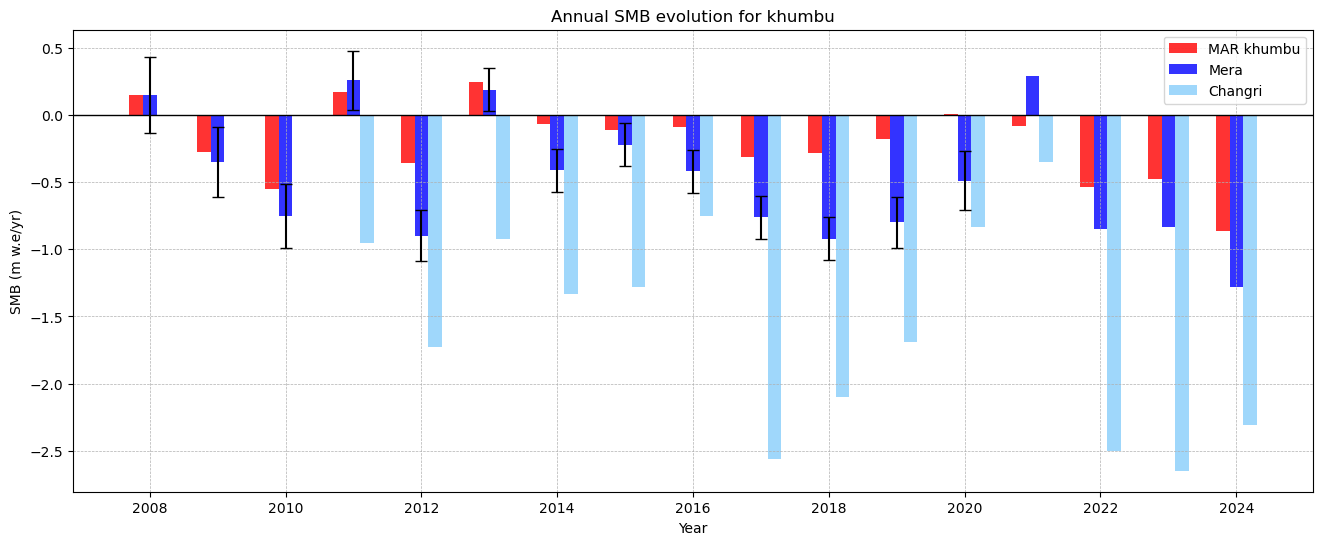

In [26]:
# Série temporelle Khumbu OBS 
plt.figure(figsize=(16,6))

SMB_cum = np.cumsum(SMB_list_khumbu)

width = 0.20 # Largeur des barres annual
offsets = [-width, 0, width] # Décalage des barres annual

series = [("MAR khumbu", SMB_list_khumbu, None, "r"),("Mera", Mera_MBgw, error_complet, "b"), ("Changri", Changri_MBgw_full, None, "lightskyblue")] # Création de la série contenant les observations et MAR

##### Annual ######
for offset, (name, values, err, color) in zip(offsets, series): # Zip permet de parcourir en parallèle offsets et series pour les associer ensemble
    plt.bar(np.array(years[:n]) + offset, values[:n], yerr=err[:n] if err is not None else None, width=width, color=color, alpha=0.8, capsize=4, ecolor='k', label=f"{name}") # yerr est une fonction matplotlib qui permet d'afficher les barres d'erreur (si pas de barre d'erreur on passe à la suite)
    
plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual SMB evolution for khumbu")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.savefig("Changri_timeseries.png")

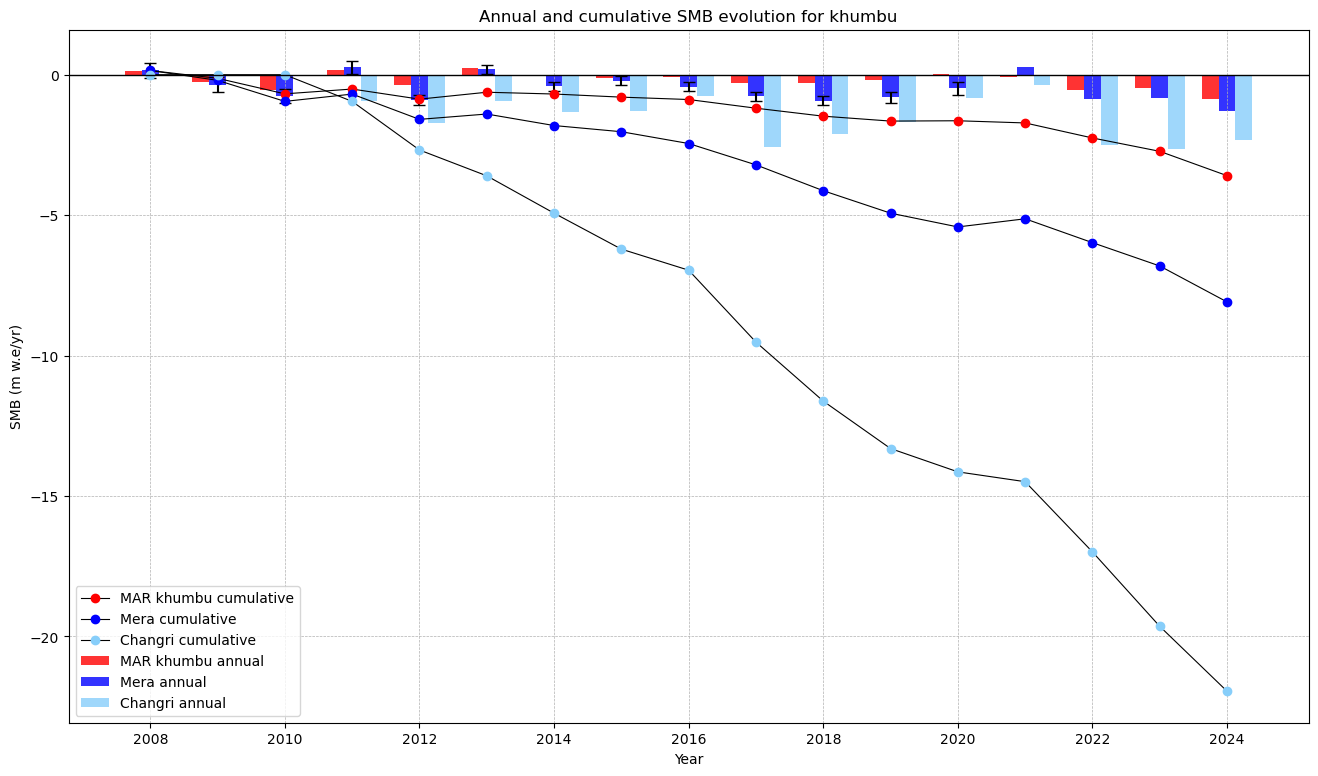

In [27]:
# Série temporelle Khumbu OBS 
plt.figure(figsize=(16,9))

SMB_cum = np.cumsum(SMB_list_khumbu)

width = 0.25 # Largeur des barres annual
offsets = [-width, 0, width] # Décalage des barres annual

series = [("MAR khumbu", SMB_list_khumbu, None, "r"),("Mera", Mera_MBgw, error_complet, "b"), ("Changri", Changri_MBgw_full, None, "lightskyblue")] # Création de la série contenant les observations et MAR

##### Annual ######
for offset, (name, values, err, color) in zip(offsets, series): # Zip permet de parcourir en parallèle offsets et series pour les associer ensemble
    plt.bar(np.array(years[:n]) + offset, values[:n], yerr=err[:n] if err is not None else None, width=width, color=color, alpha=0.8, capsize=4, ecolor='k', label=f"{name} annual") # yerr est une fonction matplotlib qui permet d'afficher les barres d'erreur (si pas de barre d'erreur on passe à la suite)

##### Cumulative ######
##### MAR ######
plt.plot(years, SMB_cum, color="k", linewidth=0.8, marker="o", markerfacecolor="r", markeredgecolor="r", label="MAR khumbu cumulative") # Cumulative SMB
##### Mera ######
plt.plot(years[:n], Mera_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="b", markeredgecolor="b", label="Mera cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée
##### Changri #####
plt.plot(years[:n], Changri_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="lightskyblue", markeredgecolor="lightskyblue", label="Changri cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB evolution for khumbu")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.savefig("Changri_timeseries.png")

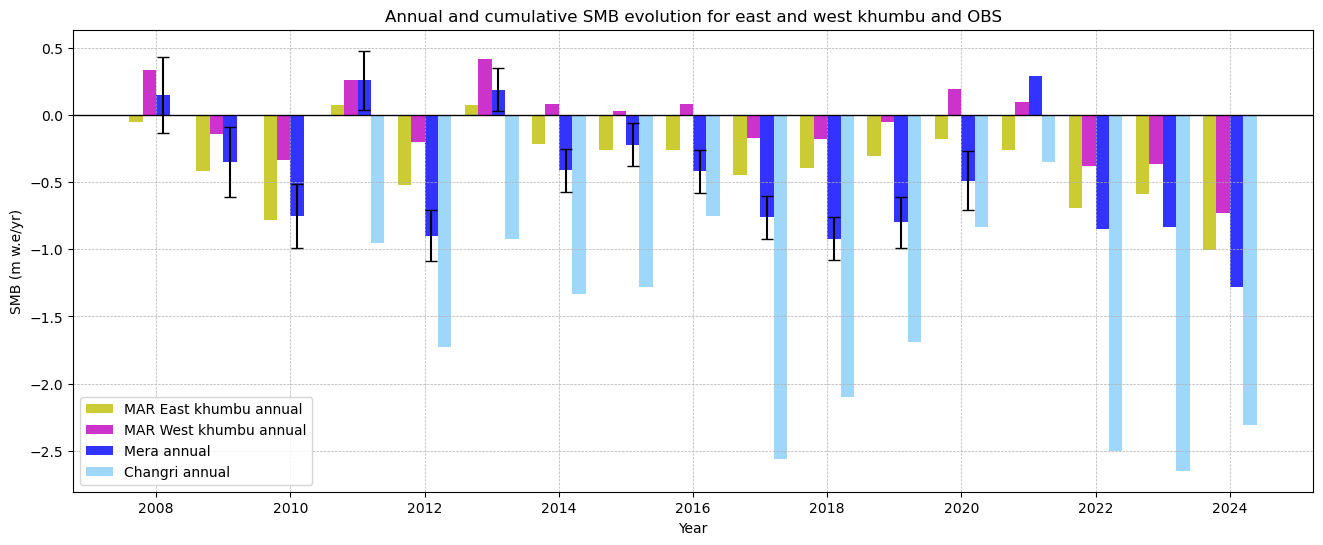

In [28]:
# Série temporelle subdomains OBS 
plt.figure(figsize=(16,6
                   ))

SMB_cum_east = np.cumsum(SMB_khumbu_east)
SMB_cum_west = np.cumsum(SMB_khumbu_west)

width = 0.20 # Largeur des barres annual
offsets = [-width*1.5, -width/2, width/2, width*1.5] # Décalage des barres annual

series = [("MAR East khumbu", SMB_khumbu_east, None, "y"), ("MAR West khumbu", SMB_khumbu_west, None, "m"),("Mera", Mera_MBgw, error_complet, "b"), ("Changri", Changri_MBgw_full, None, "lightskyblue")] # Création de la série contenant les observations et MAR

##### Annual ######
for offset, (name, values, err, color) in zip(offsets, series): # Zip permet de parcourir en parallèle offsets et series pour les associer ensemble
    plt.bar(np.array(years[:n]) + offset, values[:n], yerr=err[:n] if err is not None else None, width=width, color=color, alpha=0.8, capsize=4, ecolor='k', label=f"{name} annual") # yerr est une fonction matplotlib qui permet d'afficher les barres d'erreur (si pas de barre d'erreur on passe à la suite)

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB evolution for east and west khumbu and OBS")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.savefig("Changri_timeseries.png")

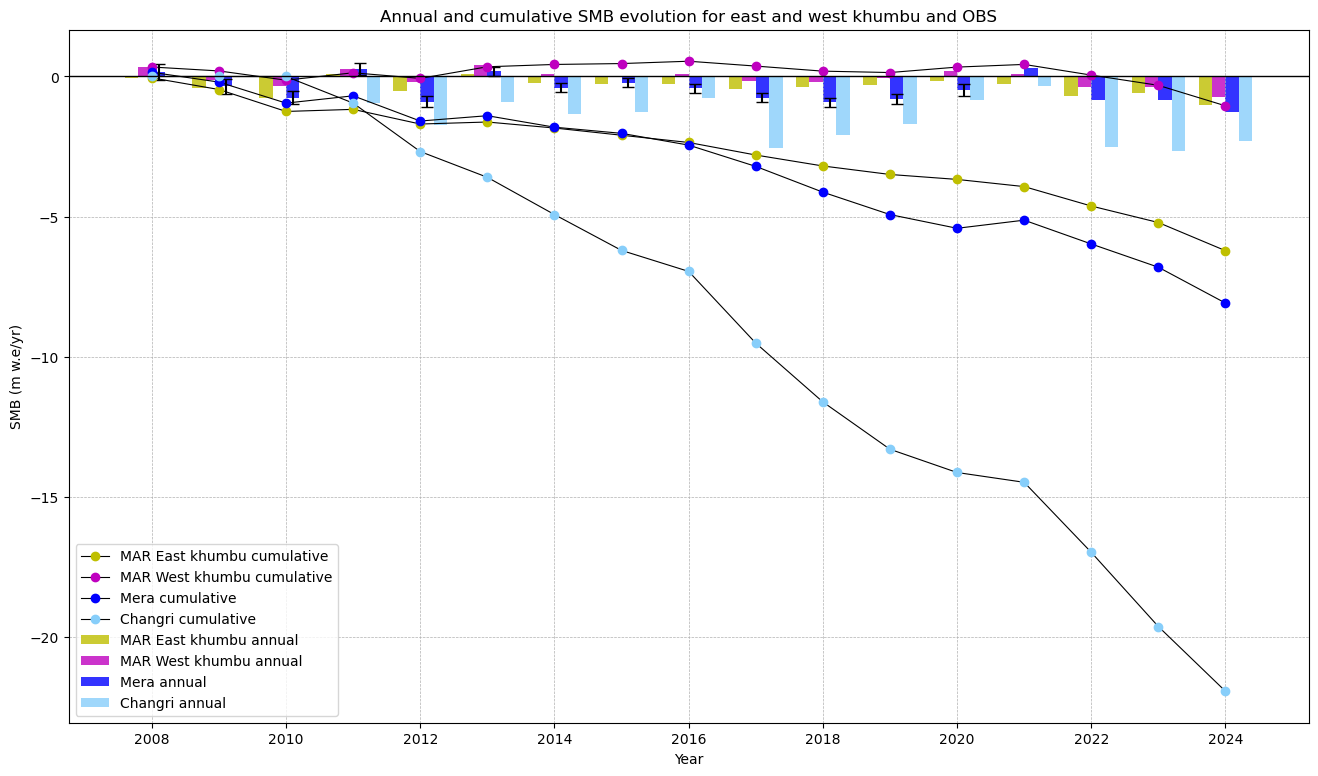

In [29]:
# Série temporelle subdomains OBS 
plt.figure(figsize=(16,9))

SMB_cum_east = np.cumsum(SMB_khumbu_east)
SMB_cum_west = np.cumsum(SMB_khumbu_west)

width = 0.20 # Largeur des barres annual
offsets = [-width*1.5, -width/2, width/2, width*1.5] # Décalage des barres annual

series = [("MAR East khumbu", SMB_khumbu_east, None, "y"), ("MAR West khumbu", SMB_khumbu_west, None, "m"),("Mera", Mera_MBgw, error_complet, "b"), ("Changri", Changri_MBgw_full, None, "lightskyblue")] # Création de la série contenant les observations et MAR

##### Annual ######
for offset, (name, values, err, color) in zip(offsets, series): # Zip permet de parcourir en parallèle offsets et series pour les associer ensemble
    plt.bar(np.array(years[:n]) + offset, values[:n], yerr=err[:n] if err is not None else None, width=width, color=color, alpha=0.8, capsize=4, ecolor='k', label=f"{name} annual") # yerr est une fonction matplotlib qui permet d'afficher les barres d'erreur (si pas de barre d'erreur on passe à la suite)

##### Cumulative ######
##### MAR East West ######
plt.plot(years, SMB_cum_east, color="k", linewidth=0.8, marker="o", markerfacecolor="y", markeredgecolor="y", label="MAR East khumbu cumulative") # Cumulative SMB
plt.plot(years, SMB_cum_west, color="k", linewidth=0.8, marker="o", markerfacecolor="m", markeredgecolor="m", label="MAR West khumbu cumulative") # Cumulative SMB
##### Mera ######
plt.plot(years[:n], Mera_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="b", markeredgecolor="b", label="Mera cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée
##### Changri #####
plt.plot(years[:n], Changri_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="lightskyblue", markeredgecolor="lightskyblue", label="Changri cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB evolution for east and west khumbu and OBS")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.savefig("Changri_timeseries.png")

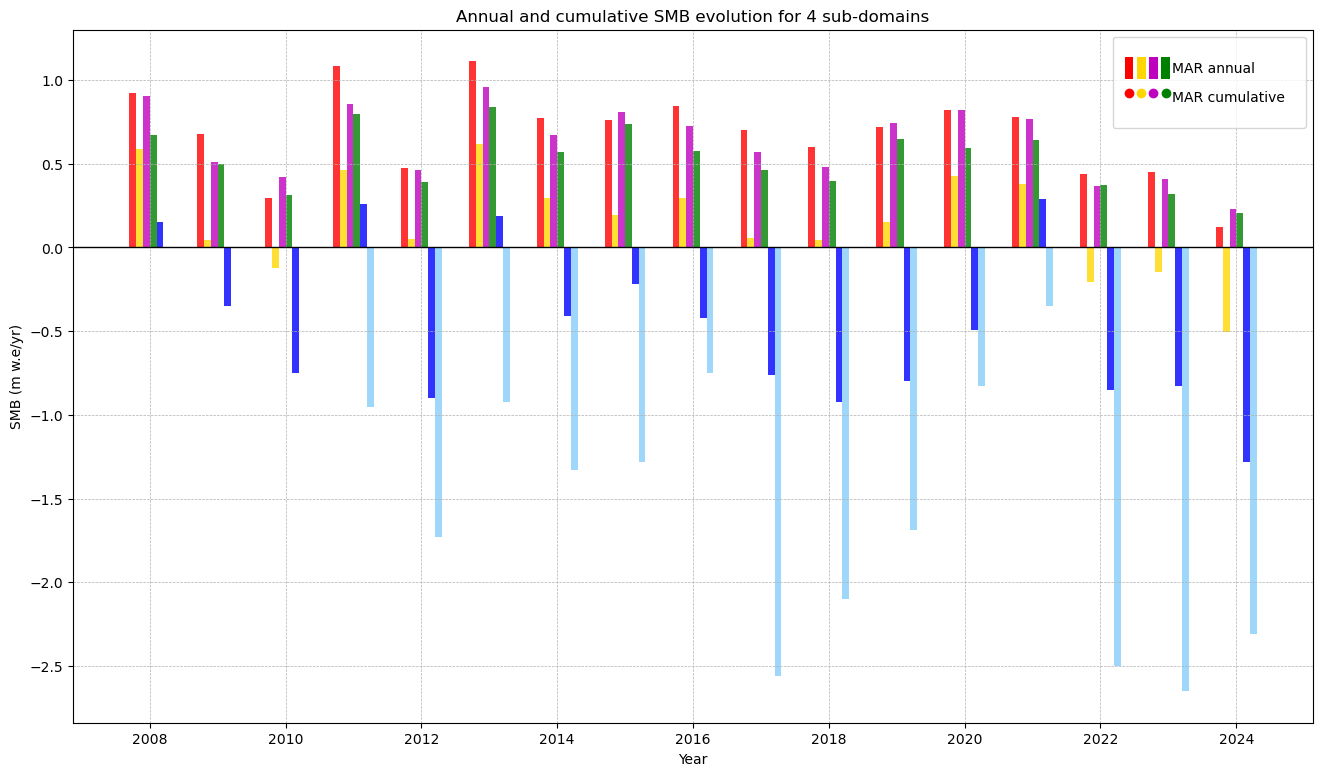

In [30]:
plt.figure(figsize=(16,9))

SMB_cum = {dom: np.cumsum(values) for dom, values in SMB_khumbu.items()} # items() retourne des tuples avec le domaine et la valeur 

colors = ["r", "gold", "m", "g"] # Définition des couleurs pour les sous domaines 

all_annual = list(SMB_khumbu.items()) + [("Mera annual", Mera_MBgw),("Changri annual", Changri_MBgw_full)] # Ajoute à la liste des 4 sous domaines les valeurs de SMB pour Mera et Changri
all_colors = colors + ["b", "lightskyblue"]

# Tuple des points et barres de couleurs des sous domaines pour annual et cumulatif
mar_handle_annual = tuple(Patch(facecolor=c) for c in colors) 
mar_handle_cum = tuple(Line2D([0], [0], marker='o', color='k', markerfacecolor=c, markeredgecolor=c, linestyle='None') for c in colors)

width = 0.10  # Largeur des barres SMB annuel
n_annual = len(all_annual)

##### Annual ######
for i, ((name, values), color) in enumerate(zip(all_annual, all_colors)):
    offset = (i - (n_annual - 1)/2) * width # Permet de voir les barres légèrement décallés
    plt.bar(np.array(years) + offset, values, color=color, alpha=0.8, width=width)

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB evolution for 4 sub-domains")
plt.grid(linestyle = '--', linewidth = 0.5)

#### Legend ####
handles, labels = plt.gca().get_legend_handles_labels() # Récupère les labels et handles de la légende (OBS)
handles.extend([mar_handle_annual, mar_handle_cum]) # Ajoute ceux de MAR
labels.extend(["MAR annual", "MAR cumulative"])
plt.legend(handles, labels, handler_map={tuple: HandlerTuple(ndivide=None)}, handleheight=2, handlelength=2, borderpad=1.5) # Le tuple indique qu'on reste sur une seule ligne et ensuite on custom la taille
plt.savefig("Changri_subdom_timeseries.png")

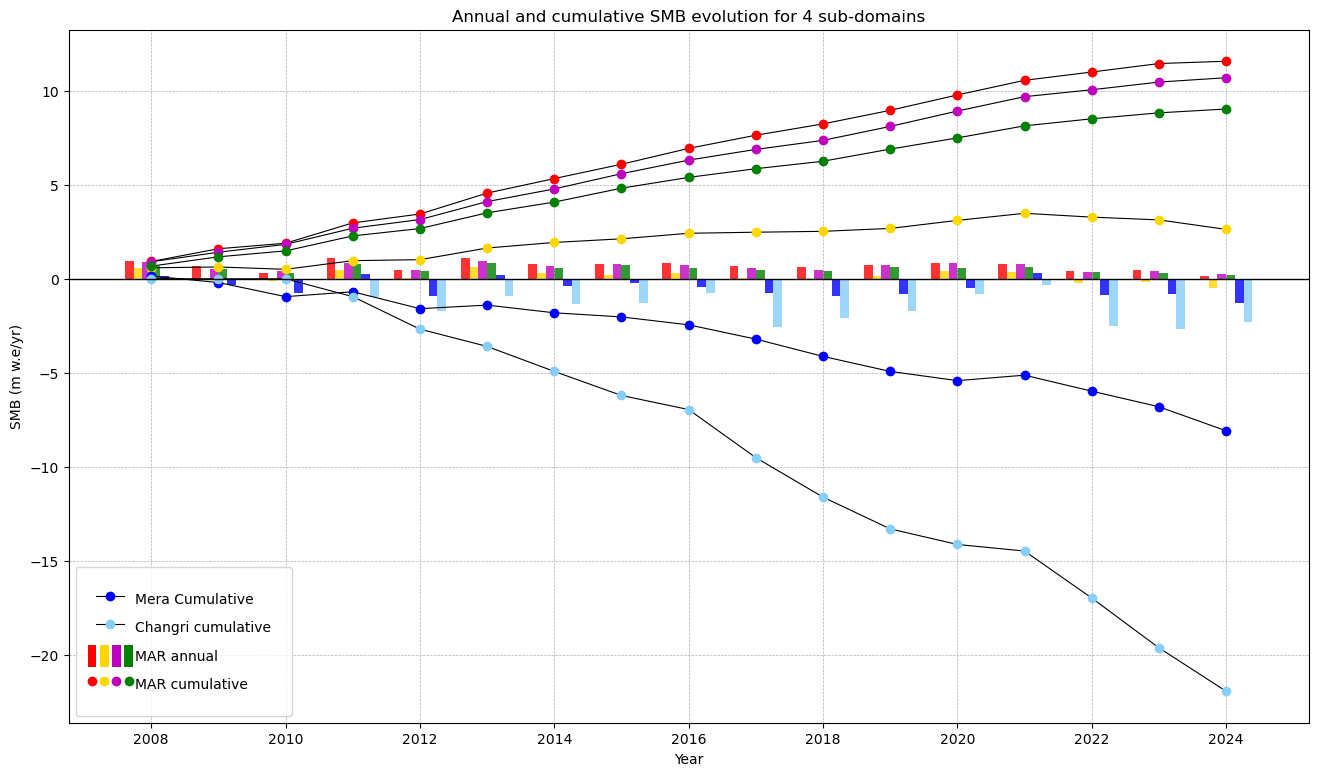

In [31]:
plt.figure(figsize=(16,9))

SMB_cum = {dom: np.cumsum(values) for dom, values in SMB_khumbu.items()} # items() retourne des tuples avec le domaine et la valeur 

colors = ["r", "gold", "m", "g"] # Définition des couleurs pour les sous domaines 

all_annual = list(SMB_khumbu.items()) + [("Mera annual", Mera_MBgw),("Changri annual", Changri_MBgw_full)] # Ajoute à la liste des 4 sous domaines les valeurs de SMB pour Mera et Changri
all_colors = colors + ["b", "lightskyblue"]

# Tuple des points et barres de couleurs des sous domaines pour annual et cumulatif
mar_handle_annual = tuple(Patch(facecolor=c) for c in colors) 
mar_handle_cum = tuple(Line2D([0], [0], marker='o', color='k', markerfacecolor=c, markeredgecolor=c, linestyle='None') for c in colors)

width = 0.13  # Largeur des barres SMB annuel
n_annual = len(all_annual)

##### Annual ######
for i, ((name, values), color) in enumerate(zip(all_annual, all_colors)):
    offset = (i - (n_annual - 1)/2) * width # Permet de voir les barres légèrement décallés
    plt.bar(np.array(years) + offset, values, color=color, alpha=0.8, width=width)

###### Cumulative ######
###### MAR subdomain ######
for i, (dom, values) in enumerate(SMB_khumbu.items()): # Enumerate permet ensuite d'utiliser un indice numérique qui boucle sur le sous domaine
    plt.plot(years, SMB_cum[dom], color="k", linewidth=0.8, marker="o", markerfacecolor=colors[i], markeredgecolor=colors[i])
##### Mera ######
plt.plot(years[:n], Mera_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="b", markeredgecolor="b", label="Mera Cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée
##### Changri #####
plt.plot(years[:n], Changri_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="lightskyblue", markeredgecolor="lightskyblue", label="Changri cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB evolution for 4 sub-domains")
plt.grid(linestyle = '--', linewidth = 0.5)

#### Legend ####
handles, labels = plt.gca().get_legend_handles_labels() # Récupère les labels et handles de la légende (OBS)
handles.extend([mar_handle_annual, mar_handle_cum]) # Ajoute ceux de MAR
labels.extend(["MAR annual", "MAR cumulative"])
plt.legend(handles, labels, handler_map={tuple: HandlerTuple(ndivide=None)}, handleheight=2, handlelength=2, borderpad=1.5) # Le tuple indique qu'on reste sur une seule ligne et ensuite on custom la taille
plt.savefig("Changri_subdom_timeseries.png")